# Prompt-only recursive still-life loop - CHIMERA for FLUX.2 + LoRA

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MNoichl/FluxFlowMorph/blob/main/notebooks/StillLife_Recursive_CHIMERA_Prompt_Only.ipynb)

This version keeps the prompt-only still-life anchor workflow and replaces
endpoint fitting with a FLUX-native port of CHIMERA (Kye et al., ECCV 2026):

1. Generate the editable cyclic `BASE_STAGES` as RIJKSOIL anchors.
2. Ask a vision-language model for one anchor-correlated prompt triplet per gap.
3. Calibrate Layer- and Timestep-wise Frequency Matching (LTM) once from a
   representative anchor subset using the paper's radial FFT descriptors.
4. Reverse the native 50-step FLUX Euler ODE for both endpoint images while
   caching the frequency-matched transformer feature at each timestep.
5. Slerp the inverted latents and caches, map inversion to denoising steps
   with IDM, and inject the matched cache through ACI (default weight 0.4).
6. Append the shared semantic-anchor tokens only during the first 20% of
   denoising, then release that constraint for fine-detail formation.
7. Render one flat ten-interior pass, save every image directly to Google
   Drive, optionally score completed pairs with DINO-backed GLCS, and finish
   the exact cyclic PNG sequence with the existing RIFE/SSIM video stack.

The official CHIMERA code was not public when this port was written.  FLUX
has no U-Net down/mid/up blocks, so this implementation follows the paper's
FLUX appendix and maps them to representative transformer depths, then
measures their timestep correspondence instead of assuming fixed thirds.
This experiment uses float16 CPU caches at every inversion step and adds
weak symmetric velocity smoothing across the complete alpha trajectory.


## 1. Editable prompt-only run, generation, CHIMERA, and video settings

`BASE_STAGES` remains the only creative input. The CHIMERA defaults mirror
the paper where they transfer directly (`lambda=0.4`, SAP ratio `0.2`, and
50 FLUX Euler steps). The `0.45` SAP gate is an endpoint-relative Qwen bridge
score rather than the paper's CLIP cosine. Cache precision, stride, and
alpha-wise velocity smoothing remain explicit experimental controls.


In [1]:
PROJECT_ROOT = "/content/FlowMorphKlein9B"
REPOSITORY_URL = "https://github.com/MNoichl/FluxFlowMorph.git"
REPOSITORY_REF = "agent/chimera-flux-flat-morph"
PROJECT_NAME = "science_path_prompt_only_chimera"
CONFIG_PATH = f"{PROJECT_ROOT}/configs/full_9b_lora.yaml"
PROFILE = "auto"
LOCAL_ASSET_ROOT = "/content/flowmorph_recursive_art"
HF_CACHE_DIR = "/content/hf_cache"

# Drive and secret. Put only the token text in this file (one line).
MOUNT_DRIVE = True
DRIVE_PROJECT_BASE = "/content/drive/MyDrive/FluxFlowMorphArt"
OPENAI_KEY_FILENAME = "openaiapikey.txt"
RESUME_RUN_DIRECTORY = None  # Example: "/content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_vision/..."

# OpenAI vision prompt generation.
OPENAI_MODEL = "gpt-5.6"
OPENAI_REASONING_EFFORT = "medium"
OPENAI_IMAGE_DETAIL = "high"  # "low", "high", "original", or "auto"
# Includes hidden reasoning plus visible structured JSON. 5000 avoids
# cutting a valid proposal off in the middle of its prompt string.
OPENAI_MAX_OUTPUT_TOKENS = 5000
OPENAI_MAX_ATTEMPTS = 3
VISION_IMAGE_MAX_SIDE = 1024
VISION_JPEG_QUALITY = 90

# Editable anchor selection and one flat CHIMERA pass.
BASE_PROMPT_COUNT = None  # None uses every entry in BASE_STAGES.
CHIMERA_ROUND_SPECS = [
    {"midpoint_count": 16},
]
CHIMERA_ALPHA_WARP_STRENGTH = 0.0  # Uniform alpha spacing; no centre warp.
INTERPOLATION_ROUNDS = len(CHIMERA_ROUND_SPECS)
REGENERATE_BASE_FRAMES = True
REUSE_EXISTING_MIDPOINTS = True
CHIMERA_INTERMEDIATE_PROMPT_MODE = "openai_per_pair"  # One stable image-aware SAP prompt for every gap.
RESUME_CHIMERA_SEQUENCE = True

# CHIMERA for the native FLUX.2 Euler flow-matching sampler.
CHIMERA_INVERSION_STEPS = 50
CHIMERA_DENOISING_STEPS = 50
CHIMERA_ACI_WEIGHT = 0.4
CHIMERA_SAP_ACTIVE_RATIO = 0.2
CHIMERA_ANCHOR_RELIABILITY_THRESHOLD = 0.45  # Fraction of the endpoint cosine gap bridged toward both sides.
CHIMERA_SAP_MAX_REQUERIES = 3
CHIMERA_ANCHOR_MAX_TOKENS = 64  # Valid Qwen tokens sampled across the complete chat sequence.
CHIMERA_LTM_MODE = "fft"  # "fft" (paper method) or explicit "linear" fallback.
CHIMERA_LTM_BANDS = 16
CHIMERA_LTM_CHANNEL_CHUNK_SIZE = 128  # Exact chunked FFT; affects memory, not results.
CHIMERA_LTM_CALIBRATION_ANCHORS = 8  # Evenly sampled from the active cyclic anchors.
REUSE_CHIMERA_LTM_CALIBRATION = True
CHIMERA_CACHE_STRIDE = 1  # Cache every inversion step for temporal fidelity.
CHIMERA_CACHE_STORAGE = "float16"  # int8, float16, bfloat16, or float32.
CHIMERA_VELOCITY_SMOOTHING_STRENGTH = 0.10  # Symmetric alpha-wise pull; endpoints stay fixed.
CHIMERA_GUIDANCE_SCALE = 7.0
CHIMERA_LORA_SCALE = 1.2
CHIMERA_CONDITIONING_INTERPOLATION = "slerp"  # Prevent midpoint embedding-norm collapse.
CHIMERA_RENDER_BATCH_SIZE = 2  # Conservative first probe.
CHIMERA_RENDER_BATCH_MAX = 10  # Maximum microbatch; smoothing still spans every interior.
CHIMERA_AUTO_RENDER_BATCH_SIZE = True
CHIMERA_BATCH_MEMORY_RESERVE_FRACTION = 0.10
CHIMERA_BATCH_MEMORY_RESERVE_GIB = 2.0
CHIMERA_BATCH_ESTIMATE_OVERHEAD = 1.25
CHIMERA_DECODE_BATCH_SIZE = 10  # VAE-only phase; OOM backoff persists the safe size.
CHIMERA_CFG_EXECUTION = "batched"
CHIMERA_BATCH_OOM_BACKOFF = True
CHIMERA_STREAM_PAIRS_PER_CHUNK = 1
CHIMERA_STREAM_DISPLAY_PROGRESS = True
OPENAI_CONCURRENCY = 6

# Optional pairwise paper metric. DINO was the best-performing alternative
# similarity in the paper's supplemental comparison; disabled by default to
# avoid another model download.
RUN_CHIMERA_DINO_GLCS = False
CHIMERA_DINO_MODEL_ID = "facebook/dinov2-base"
CHIMERA_GLCS_GAMMA = 2.0

# FLUX.2 Klein Base 9B + RIJKSOIL LoRA.
MODEL_ID = "Runware/BFL-FLUX.2-klein-base-9B"
MODEL_REVISION = "52d7274119d8a2b67f4fba1a43694d9169a44851"
LORA_SOURCE = "MaxNoichl/RIJKSOIL_FLUX2_KLEIN9B_lora_01_000001650"
LORA_REVISION = "042a31d6cd09bf55195f820461fac60b1a358409"
LORA_WEIGHT_NAME = "RIJKSOIL_FLUX2_KLEIN9B_lora_01_000001650.safetensors"
LORA_ADAPTER_NAME = "rijks_oil"
LORA_TRIGGER = "RIJKSOIL"

IMAGE_WIDTH = 1024
IMAGE_HEIGHT = 1024
IMAGE_INFERENCE_STEPS = 50
IMAGE_GUIDANCE_SCALE = 7.0
IMAGE_LORA_SCALE = 1.2
BASE_SEED = None  # Generated from OS entropy and persisted per run below.
BASE_PIPELINE_CPU_OFFLOAD = False  # False keeps the fused base pipeline resident on high-VRAM GPUs.

# Weak continuity applies only to standalone anchor generation.
BASE_CONTINUITY_ENABLED = True
BASE_REFERENCE_STRENGTH = 0.6 # Blend of the blurred previous anchor into the warm field.
BASE_REFERENCE_BLUR = 10.0
BASE_REFERENCE_GRAIN_STRENGTH = 0.035  # Normalized monochrome noise sigma; 0 disables.
REFERENCE_BACKGROUND = (116, 105, 91)
SAVE_SOFT_REFERENCES = True  # Inspect in base_frames/soft_references.
FLUX_PROMPT_MAX_SEQUENCE_LENGTH = 512

# Optional post-CHIMERA tone/chroma correction; raw PNGs are never overwritten.
TEMPORAL_TONE_STABILIZATION_ENABLED = False  # Luminance/contrast outlier correction.
TEMPORAL_TONE_WINDOW_RADIUS = 2
TEMPORAL_TONE_STRENGTH = 0.70
TEMPORAL_TONE_MEAN_THRESHOLD = 0.02
TEMPORAL_TONE_CONTRAST_THRESHOLD = 0.10
TEMPORAL_TONE_MAD_MULTIPLIER = 3.5
TEMPORAL_TONE_MAX_MEAN_SHIFT = 0.06
TEMPORAL_TONE_MAX_CONTRAST_SCALE_DELTA = 0.15
TEMPORAL_TONE_ANALYSIS_MAX_SIDE = 256
TEMPORAL_TONE_REUSE_EXISTING = True
TEMPORAL_CHROMA_STABILIZATION_ENABLED = True
TEMPORAL_CHROMA_STRENGTH = 0.70  # Pull the measured trajectory toward the endpoint line.
TEMPORAL_CHROMA_THRESHOLD = 0.01  # Ignore signed adjustments below one percent.
TEMPORAL_CHROMA_MAX_GAIN = 0.12  # At most a twelve-percent chroma lift.
TEMPORAL_CHROMA_MAX_DECREASE = 0.08  # At most an eight-percent chroma reduction.
TEMPORAL_CHROMA_SMOOTHNESS = 6.0  # Second-difference penalty on the desired output trajectory.

# Read-only diagnosis of raw cyclic CHIMERA output.
RUN_FLICKER_DIAGNOSTIC = True
FLICKER_ANALYSIS_MAX_SIDE = 256
FLICKER_OUTLIER_MAD_MULTIPLIER = 3.5
FLICKER_MINIMUM_OUTLIER_SCORE = 3.0
FLICKER_MAX_LAG = 64

# Trial and notebook display.
RUN_TRIAL_KEYFRAME = True
TRIAL_KEYFRAME_INDEX = None  # None chooses randomly; otherwise 0..BASE_PROMPT_COUNT-1.
TRIAL_SEED = None
TRIAL_DISPLAY_MAX_WIDTH = 768
RUN_CHIMERA_ONE_GAP_TEST = True
CHIMERA_ONE_GAP_TEST_INDEX = 0
# The one-gap gate derives its alphas from CHIMERA_ROUND_SPECS[0] and CHIMERA_ALPHA_WARP_STRENGTH.
CONTACT_SHEET_COLUMNS = 8
CONTACT_SHEET_DISPLAY_MAX_WIDTH = 1100
LOOP_PREVIEW_DISPLAY_WIDTH = 768
LOOP_PREVIEW_RENDER_MAX_SIDE = 512  # Reduced streaming preview; source PNGs stay untouched.

# Cyclic sequence and RIFE/SSIM finishing.
VIDEO_SLOWDOWN_FACTOR = 4.0
SOURCE_SEQUENCE_FPS = 12.0 / VIDEO_SLOWDOWN_FACTOR
LOOP_AUTO_ROTATE_TO_QUIETEST_CUT = True
LOOP_SEAM_ANALYSIS_SIZE = 192
RUN_RIFE_POSTPROCESS = True
RIFE_REPOSITORY_URL = "https://github.com/hzwer/Practical-RIFE.git"
RIFE_REPOSITORY_REVISION = "17d8c7a1005b37f4c97bfee04e316aaec7fdc536"
RIFE_ROOT = "/content/Practical-RIFE"
RIFE_MODEL_REPOSITORY = "Bash2X/RIFE-Models"
RIFE_MODEL_REVISION = "feaf6d11238b4a1e9f015a5d18c18df152affd20"
RIFE_MODEL_FILENAME = "RIFE_v4.25.zip"
RIFE_MULTIPLIER = 24  # Dense candidate pool; final 4x timing needs only 8 per source edge.
RIFE_PERCEPTUAL_ALLOCATION = True  # Redistribute the same total RIFE budget toward larger frame gaps.
RIFE_DISTANCE_ANALYSIS_SIZE = 192
RIFE_MIN_PAIR_MULTIPLIER = 2
RIFE_MAX_PAIR_MULTIPLIER = int(round(2 * RIFE_MULTIPLIER))
RIFE_DISTANCE_WEIGHT_CLIP = 2.5  # Cap any gap at this multiple of the median distance.
RIFE_SCALE = 1.0
RIFE_BATCH_SIZE = 4
RIFE_USE_FP16 = True
RIFE_RETRY_WITH_FP32 = True  # Automatically retry once when the fp16 runner fails.
RIFE_FINAL_FPS = 24.0
RIFE_SSIM_ANALYSIS_SIZE = 192
RIFE_SSIM_WEIGHT_FLOOR = 1e-6
RIFE_VIDEO_CRF = 16
RIFE_KEEP_WORK_FRAMES = False
RIFE_DISPLAY_WIDTH = 768
DOWNLOAD_FINAL_VIDEO = False


## 2. Editable anchor sciences and prompts

Edit these dictionaries directly. `science` is sent to the vision model as conceptual context; `prompt` is sent to FLUX. Every prompt must be a literal visual description and must contain the LoRA trigger `RIJKSOIL`. Avoid production-language such as “bridge frame,” “keep,” “same,” or “transition.”


In [2]:
BASE_STAGES = [
    
    
    {
        "id": "01_astronomy",
        "science": "Astronomy & Astrophysics",
        "prompt": "RIJKSOIL, a minimalist modernist still life of the cosmos: a single smooth grey sphere, a thin metal ring standing for the armillary, a slender pointer, and a scatter of a few small pale dots. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of dusty slate-blue and pale grey, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
    {
        "id": "02_physics",
        "science": "Nuclear, High-Energy, Atomic & Optical Physics",
        "prompt": "RIJKSOIL, a minimalist modernist still life of matter and light: a small celadon-green glass vessel, a clear triangular prism, a dense dark cube, and a single fine spiralling wire. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of muted celadon green and cool grey, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
    {
        "id": "03_chemistry_materials",
        "science": "Chemistry & Materials (Organic, Analytical, Materials, Polymers)",
        "prompt": "RIJKSOIL, a minimalist modernist still life of chemistry: a round-bottomed flask, a slender test tube, a plain bowl, and a single faceted crystal. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of warm ochre and soft terracotta, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
    {
        "id": "04_geosciences",
        "science": "Geosciences (Water, Atmosphere, Geophysics, Planetary)",
        "prompt": "RIJKSOIL, a minimalist modernist still life of the earth: a matte terrestrial sphere, a smooth grey stone, a tall glass half-filled with layered sediment, and a plain round dial. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of pale mineral blue-grey and soft sage, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
    {
        "id": "05_ecology_evolution",
        "science": "Ecology & Evolution",
        "prompt": "RIJKSOIL, a minimalist modernist still life of life and deep time: a single fern frond, a smooth spiral shell, a pale egg, and a bare branching twig. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of muted sage-green and dusty umber, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
    {
        "id": "06_botany",
        "science": "Botany, Plant & Food Science",
        "prompt": "RIJKSOIL, a minimalist modernist still life of the plant kingdom: a slim vase holding two or three simple stems, a single ripe pear, one broad leaf, and a small bundle of wheat. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of soft olive-green with faded rose and cream, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
    {
        "id": "07_genetics_cell",
        "science": "Genetics, Cell & Molecular Biology",
        "prompt": "RIJKSOIL, a minimalist modernist still life of heredity and the cell: a pomegranate halved to show its packed round seeds, a small cluster of identical pale spheres, a single coiled tendril, and a plain glass lens. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of pale putty, chalk-white, and soft blush, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
    {
        "id": "08_medicine_disease",
        "science": "Medicine: Disease, Immunity & Remedy (Immunology, Pharmacology, Oncology)",
        "prompt": "RIJKSOIL, a minimalist modernist still life of remedy and contagion: two or three plain apothecary bottles, a slim sealed phial of muted brick-red, a curl of pale bark, and, set quietly back, a simple Venetian plague-doctor's mask reduced to its long curved beak and two round eyeholes. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of cool bone-grey and pale ash with a muted brick-red, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
    {
        "id": "09_anatomy_physiology",
        "science": "Anatomy, Surgery, Cardiology & Physiology",
        "prompt": "RIJKSOIL, a minimalist modernist still life of the body's workings: a smooth wax model of a heart, an hourglass, a single slim blade, and a coiled glass tube. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of dusty terracotta-rose, bone, and cool grey, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
    {
        "id": "10_neuroscience_mind",
        "science": "Neuroscience, Psychiatry & Psychology",
        "prompt": "RIJKSOIL, a minimalist modernist still life of the mind: a smooth pale brain form under a glass dome, a plain round mirror reflecting soft light, a single pendulum bob on a thread, and one dark inkblot on white paper. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of muted periwinkle and dove-grey, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
    {
        "id": "11_philosophy_society",
        "science": "Philosophy & the Social Sciences",
        "prompt": "RIJKSOIL, a minimalist modernist still life of thought and society: a smooth pale skull, a short stack of plain books, a single geometric solid, a matte sphere, and a simple two-pan balance. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of warm taupe, ochre, and soft gold, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
    {
        "id": "12_computation_math",
        "science": "Computer Science, AI & Mathematics",
        "prompt": "RIJKSOIL, a minimalist modernist still life of pure form: a few nested geometric solids, a pair of dividers, a plain frame of beads like an abacus, and a single ring standing for an orbit, its line completing back toward the sphere where the journey began. A few simple objects set with generous negative space on a plain matte surface against a soft flat ground, even diffuse light with no harsh shadows, reduced geometric forms and smooth matte finishes, a muted chalky palette of cool pale grey and putty turning toward slate-blue, calm, spare, and contemplative, in the reductive spirit of Giorgio Morandi.",
    },
]





# [
#     {
#         "id": "01_astronomy",
#         "science": "Astronomy & Astrophysics",
#         "prompt": "RIJKSOIL, a hushed Baroque still life of the heavens brought indoors: a tarnished brass armillary sphere and a celestial globe painted with constellations, an astrolabe and a small orrery, bronze dividers resting on a curling star chart, a pitted meteorite and a shard of quartz catching the light. A single candle stands in for a distant sun on black velvet strewn with faint points of starlight. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, a cold indigo-black palette shot with silver starlight and old brass, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     },
#     {
#         "id": "02_physics",
#         "science": "Nuclear, High-Energy, Atomic & Optical Physics",
#         "prompt": "RIJKSOIL, a Baroque still life of matter and light: a goblet of uranium glass fluorescing eerie green beside a lead casket cracked to show a faintly glowing vial, a gold-leaf electroscope and a brass tuning fork, a glass prism splitting the candle's beam into a spectral ribbon across polished lenses, and a cloud chamber where fine spiral tracks hang like frozen lightning. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, black and lead-grey lit by uranium-green fluorescence, a prismatic rainbow, and one gold spark, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     },
#     {
#         "id": "03_chemistry_materials",
#         "science": "Chemistry & Materials (Organic, Analytical, Materials, Polymers)",
#         "prompt": "RIJKSOIL, an alchemical Baroque still life of transformation: a glass alembic and a pear-shaped retort of jewel-coloured liquids, a coiled condenser and a rack of test tubes glowing ruby and cobalt, a burner flame licked green and copper by unseen salts, a brass ball-and-stick molecule, a cluster of iridescent bismuth crystals, a coil of amber resin with an insect trapped inside, and a stone mortar and pestle. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, deep amber and ruby glass with copper-flame green and an iridescent metallic sheen, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     },
#     {
#         "id": "04_geosciences",
#         "science": "Geosciences (Water, Atmosphere, Geophysics, Planetary)",
#         "prompt": "RIJKSOIL, a Baroque still life of earth and sky: banded agates and mineral specimens, a brass barometer and a glass of layered water and sediment, a small seismograph drum trailing a jagged line, a fossil-bearing rock, and a terrestrial globe half wrapped in drifting mist. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, cool mineral aqua, slate-blue, and misty green, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     },
#     {
#         "id": "05_ecology_evolution",
#         "science": "Ecology & Evolution",
#         "prompt": "RIJKSOIL, a Baroque still life of the living web and deep time: a bird's nest of speckled eggs among ferns and lichened bark, iridescent beetles and a poised butterfly, a spiral ammonite and a ridged trilobite half-freed from a broken slab of grey limestone with their coils still embedded in the stone, a fern frond pressed as a dark imprint in split shale, a branching red coral for the tree of life, a single weathered skull set back in shadow, and an open naturalist's notebook of careful pencil studies. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, wet forest greens and moss shading into fossil grey-green and bone-ochre, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     },
#     {
#         "id": "06_botany",
#         "science": "Botany, Plant & Food Science",
#         "prompt": "RIJKSOIL, an opulent Baroque flower and harvest still life in the manner of Rachel Ruysch: tumbling tulips, roses, and poppies just past their prime, an herbarium sheet with a pinned specimen, a magnifier over a veined leaf, split figs and a broken pomegranate, a sheaf of wheat, and a dark loaf beside a comb of honey. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, verdant leaf-green with ripe fruit-reds and gold, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     },
#     {
#         "id": "07_genetics_cell",
#         "science": "Genetics, Cell & Molecular Biology",
#         "prompt": "RIJKSOIL, a Baroque still life where heredity meets the cell: a spiralling pea tendril twisting like a double helix and open pods with sorted green and yellow peas, beside a pomegranate split to packed glistening arils, a fig cut to its seeded interior, a heaped cluster of translucent gooseberries and glossy fish roe, a comb of honey with rows of hexagonal chambers, and an antique brass microscope whose lens throws a bright disc crowded with round cells caught mid-division. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, pale pearl, milky rose, and soft gold, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     },
#     {
#         "id": "08_medicine_disease",
#         "science": "Medicine: Disease, Immunity & Remedy (Immunology, Pharmacology, Oncology)",
#         "prompt": "RIJKSOIL, a grave Baroque still life of contagion, remedy, and blood: a pierced silver pomander of dried herbs against the miasma, a curl of bitter cinchona bark, sprigs of rue and rosemary bound with twine, labelled apothecary jars of poppy and foxglove, a hand-blown phial sealed with dark wax, a brass-and-ivory bloodletting fleam, a stoppered flask of dark crimson beside a pale crab laid on cold stone for the old name of the disease, and an old beaked plague-doctor's mask of cracked dark leather, its glass eyes clouded, quiet in the shadow to one side. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, tarnished silver and apothecary amber shading toward blood-crimson, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     },
#     {
#         "id": "09_anatomy_physiology",
#         "science": "Anatomy, Surgery, Cardiology & Physiology",
#         "prompt": "RIJKSOIL, a solemn Baroque anatomical still life: a small écorché figure and a wax model of the human heart, a gleaming scalpel, forceps, and bone-saw, a Vesalian atlas open to an engraved plate, an hourglass with sand mid-fall and a coiled glass tube, a comb of honey dripping slow for the blood's sweetness, a skull, and a translucent plate glowing faintly like an early radiograph. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, carmine flesh, ivory bone, and cold steel cooling toward a pale radiograph blue, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     },
#     {
#         "id": "10_neuroscience_mind",
#         "science": "Neuroscience, Psychiatry & Psychology",
#         "prompt": "RIJKSOIL, a Baroque still life of the thinking organ and the interior mind: a human brain suspended in a bell-jar of clear spirit, branching coral and bare winter twigs echoing dendrites, a phrenology bust incised with regions, a faint electric spark leaping a gap, a clouded mirror holding a half-lit face, two theatrical masks of comedy and grief, a slow pendulum, and a single inkblot bleeding on parchment. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, electric blue-violet and shadowed indigo with mirror-silver, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     },
#     {
#         "id": "11_philosophy_society",
#         "science": "Philosophy & the Social Sciences",
#         "prompt": "RIJKSOIL, a Baroque vanitas of thought and society: a skull resting on a stack of worn leather books, a snuffed candle trailing smoke, an hourglass and a quill in its inkwell, five Platonic solids in glass, an owl in shadow, and beside them brass scales of justice weighing gold coins against a folded contract, an abacus and an open ledger, ivory dice and playing cards for the games of strategy, and a globe half-turned to the dark. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, warm sepia, candle-gold, and coin-gold, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     },
#     {
#         "id": "12_computation_math",
#         "science": "Computer Science, AI & Mathematics",
#         "prompt": "RIJKSOIL, a Baroque still life of pure form and mechanism: an abacus and brass dividers over Euclid's open geometry, interlocking clockwork gears, a chessboard caught mid-game, nested Platonic solids and a small orrery, a perforated brass plate like a punched card, and a single lens turned outward. The candle gutters low, its light circling back toward the stars where the journey began. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, cool brass and silver on black turning toward cosmic indigo, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush."
#     }
# ]


## 3. GPU, repository, and compatible dependencies

This checks the actual imports needed by the notebook. It does not reject a healthy Diffusers install merely because editable-install provenance metadata is absent. A core reinstall happens only if a clean Python process cannot import the FLUX.2 Klein pipeline and required packages; in that case restart the kernel once after installation.


In [3]:
import platform
import subprocess
import sys
from pathlib import Path

print({"python": sys.version, "platform": platform.platform()})
try:
    import torch
except ImportError as error:
    raise RuntimeError("PyTorch is missing; use a Colab GPU runtime and rerun this cell.") from error
if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU runtime is required.")
print({"gpu": torch.cuda.get_device_name(0), "cuda": torch.version.cuda})

project_path = Path(PROJECT_ROOT)
if not (project_path / "pyproject.toml").is_file():
    subprocess.check_call([
        "git", "clone", "--depth", "1", "--branch", REPOSITORY_REF,
        "--single-branch", REPOSITORY_URL, PROJECT_ROOT,
    ])
else:
    subprocess.check_call([
        "git", "-C", PROJECT_ROOT, "fetch", "--depth", "1",
        "origin", REPOSITORY_REF,
    ])
    subprocess.check_call([
        "git", "-C", PROJECT_ROOT, "checkout", "--detach", "FETCH_HEAD",
    ])
chimera_source = project_path / "src" / "flowmorph_klein" / "chimera.py"
if not chimera_source.is_file():
    raise RuntimeError(
        f"Repository ref {REPOSITORY_REF!r} does not contain {chimera_source}. "
        "Rerun this setup cell to refresh the requested ref."
    )

core_probe = subprocess.run(
    [
        sys.executable,
        "-c",
        "import numpy, scipy, transformers, pydantic; from diffusers import Flux2KleinPipeline",
    ],
    capture_output=True,
    text=True,
)
if core_probe.returncode != 0:
    print("Installing the notebook's pinned FLUX environment because the clean import probe failed:")
    print(core_probe.stderr[-2000:])
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-r",
        str(project_path / "requirements-colab.txt"),
    ])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", PROJECT_ROOT])
    raise RuntimeError(
        "Dependencies installed successfully. Restart the notebook kernel once, then rerun from section 1."
    )

try:
    import openai
    from openai import OpenAI
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openai>=2,<3"])
    import openai
    from openai import OpenAI

import importlib
package_source = str(project_path / "src")
if package_source not in sys.path:
    sys.path.insert(0, package_source)
importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == "flowmorph_klein" or module_name.startswith("flowmorph_klein."):
        del sys.modules[module_name]
import flowmorph_klein
importlib.import_module("flowmorph_klein.chimera")
from diffusers import Flux2KleinPipeline

project_commit = subprocess.check_output(
    ["git", "-C", PROJECT_ROOT, "rev-parse", "HEAD"], text=True
).strip()
print({
    "repository_ref": REPOSITORY_REF,
    "repository_commit": project_commit,
    "flowmorph_source": flowmorph_klein.__file__,
    "openai_sdk": openai.__version__,
})


{'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35'}
{'gpu': 'NVIDIA RTX PRO 6000 Blackwell Server Edition', 'cuda': '12.8'}


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


{'repository_ref': 'agent/chimera-flux-flat-morph', 'repository_commit': '7ba4f7f2acbac6c74a6d9f1a156ea99160885d90', 'flowmorph_source': '/content/FlowMorphKlein9B/src/flowmorph_klein/__init__.py', 'openai_sdk': '2.45.0'}


## 4. Mount Drive, reserve the run directory, and load the API key

Create `openaiapikey.txt` directly inside `DRIVE_PROJECT_BASE`. The file should contain only the API key and a final newline is optional. It is read into the OpenAI client and then the temporary string is deleted. The notebook prints the path it read, never the key or any key fragment.


In [4]:
import json
import re
from datetime import datetime, timezone

if not re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_-]*", PROJECT_NAME):
    raise ValueError("PROJECT_NAME may contain only letters, numbers, underscores, and hyphens")

DRIVE_ENABLED = False
if MOUNT_DRIVE:
    try:
        from google.colab import drive
    except ImportError as error:
        raise RuntimeError("Drive mounting requires a Google Colab kernel.") from error
    drive.mount("/content/drive")
    drive_base = Path(DRIVE_PROJECT_BASE)
    drive_base.mkdir(parents=True, exist_ok=True)
    DRIVE_ENABLED = True
else:
    drive_base = None

def reserve_numbered_run(parent, project_name):
    project_root = Path(parent) / project_name
    project_root.mkdir(parents=True, exist_ok=True)
    numbers = []
    prefix = f"{project_name}_"
    for candidate in project_root.iterdir():
        if candidate.is_dir() and candidate.name.startswith(prefix):
            token = candidate.name[len(prefix):].split("_", 1)[0]
            if token.isdigit():
                numbers.append(int(token))
    sequence = max(numbers, default=0) + 1
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    while True:
        candidate = project_root / f"{project_name}_{sequence:04d}_{timestamp}"
        try:
            candidate.mkdir(parents=False, exist_ok=False)
        except FileExistsError:
            sequence += 1
            continue
        return candidate

if RESUME_RUN_DIRECTORY is not None:
    RUN_DIRECTORY = Path(RESUME_RUN_DIRECTORY).expanduser()
    if not RUN_DIRECTORY.is_dir():
        raise FileNotFoundError(f"RESUME_RUN_DIRECTORY does not exist: {RUN_DIRECTORY}")
elif DRIVE_ENABLED:
    RUN_DIRECTORY = reserve_numbered_run(drive_base, PROJECT_NAME)
else:
    RUN_DIRECTORY = reserve_numbered_run(LOCAL_ASSET_ROOT, PROJECT_NAME)

for child in ("base_frames", "trials", "rounds", "previews", "video", "metadata"):
    (RUN_DIRECTORY / child).mkdir(parents=True, exist_ok=True)
Path(HF_CACHE_DIR).mkdir(parents=True, exist_ok=True)

if not DRIVE_ENABLED:
    raise RuntimeError(
        "This notebook's OpenAI key workflow expects Google Drive. Set MOUNT_DRIVE=True."
    )
OPENAI_KEY_PATH = drive_base / OPENAI_KEY_FILENAME
if not OPENAI_KEY_PATH.is_file():
    raise FileNotFoundError(
        f"Create {OPENAI_KEY_PATH} with only your OpenAI API key, then rerun this cell."
    )
_openai_key = OPENAI_KEY_PATH.read_text(encoding="utf-8").strip()
if len(_openai_key) < 20 or any(character.isspace() for character in _openai_key):
    raise ValueError("The Drive key file is empty or malformed; expected one token with no spaces.")
OPENAI_CLIENT = OpenAI(api_key=_openai_key)
del _openai_key

import secrets

SEED_MANIFEST_PATH = RUN_DIRECTORY / "metadata" / "run_seed.json"
existing_base_manifest = RUN_DIRECTORY / "metadata" / "base_manifest.json"
if SEED_MANIFEST_PATH.is_file():
    seed_payload = json.loads(SEED_MANIFEST_PATH.read_text(encoding="utf-8"))
    BASE_SEED = int(seed_payload["base_seed"])
    seed_source = "persisted_run_seed"
elif RESUME_RUN_DIRECTORY is not None and existing_base_manifest.is_file():
    existing_base_payload = json.loads(existing_base_manifest.read_text(encoding="utf-8"))
    existing_records = existing_base_payload.get("records", [])
    if not existing_records:
        raise RuntimeError("Cannot recover the seed from an empty resumed base manifest")
    BASE_SEED = int(existing_records[0]["seed"])
    seed_source = "recovered_from_base_manifest"
else:
    BASE_SEED = secrets.randbelow(2**63 - len(BASE_STAGES))
    seed_source = "os_entropy"
if not 0 <= BASE_SEED < 2**63:
    raise ValueError("Persisted BASE_SEED is outside the supported range")
SEED_MANIFEST_PATH.write_text(json.dumps({
    "base_seed": BASE_SEED,
    "source": seed_source,
}, indent=2) + "\n", encoding="utf-8")

run_identity = {
    "project": PROJECT_NAME,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "persistent": DRIVE_ENABLED,
    "run_directory": str(RUN_DIRECTORY),
    "openai_model": OPENAI_MODEL,
    "base_seed": BASE_SEED,
    "key_file": str(OPENAI_KEY_PATH),
    "key_value_recorded": False,
}
(RUN_DIRECTORY / "metadata" / "run_identity.json").write_text(
    json.dumps(run_identity, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print("OpenAI client initialized from the Drive key file (credential value not displayed).")
print("Run directory:", RUN_DIRECTORY)
print("Random run seed:", BASE_SEED, f"({seed_source})")
print("Every generated image and manifest is written directly into this persistent directory.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OpenAI client initialized from the Drive key file (credential value not displayed).
Run directory: /content/drive/MyDrive/FluxFlowMorphArt/science_path_prompt_only_chimera/science_path_prompt_only_chimera_0019_20260804T221412Z
Random run seed: 6094362728914526771 (os_entropy)
Every generated image and manifest is written directly into this persistent directory.


## 5. Resolve sequence settings and preview cost

This resolves automatic sequence values and estimates the expensive pairwise
inversions and denoising batches. Component-specific settings are checked only
when that component is used, so experimental parameters remain editable.


In [5]:
import math

# Resolve only values needed to build the sequence and cost preview.
if BASE_PROMPT_COUNT is None:
    BASE_PROMPT_COUNT = len(BASE_STAGES)
else:
    BASE_PROMPT_COUNT = int(BASE_PROMPT_COUNT)
if not 2 <= BASE_PROMPT_COUNT <= len(BASE_STAGES):
    raise ValueError(f"BASE_PROMPT_COUNT must be between 2 and {len(BASE_STAGES)}")
if not CHIMERA_ROUND_SPECS:
    raise ValueError("CHIMERA_ROUND_SPECS needs at least one round")
midpoint_counts = [int(spec["midpoint_count"]) for spec in CHIMERA_ROUND_SPECS]
if any(count < 1 for count in midpoint_counts):
    raise ValueError("Each midpoint_count must be positive")
if min(CHIMERA_RENDER_BATCH_SIZE, CHIMERA_RENDER_BATCH_MAX) < 1:
    raise ValueError("CHIMERA render batch sizes must be positive")

ACTIVE_BASE_STAGES = BASE_STAGES[:BASE_PROMPT_COUNT]
ids = [item["id"] for item in ACTIVE_BASE_STAGES]
if len(ids) != len(set(ids)):
    raise ValueError("Anchor IDs must be unique to avoid overwriting files")

round_counts = [BASE_PROMPT_COUNT]
for midpoint_count in midpoint_counts:
    round_counts.append(round_counts[-1] * (midpoint_count + 1))
pair_count = sum(round_counts[:-1])
denoise_batches_initial = sum(
    round_counts[index] * math.ceil(
        midpoint_counts[index] / CHIMERA_RENDER_BATCH_SIZE
    )
    for index in range(len(CHIMERA_ROUND_SPECS))
)
denoise_batches_best_case = sum(
    round_counts[index] * math.ceil(
        midpoint_counts[index] / CHIMERA_RENDER_BATCH_MAX
    )
    for index in range(len(CHIMERA_ROUND_SPECS))
)
print({
    "anchor_images": BASE_PROMPT_COUNT,
    "sequence_counts": round_counts,
    "openai_anchor_triplets": pair_count,
    "endpoint_inversions": pair_count * 2,
    "inversion_transformer_calls": pair_count * 2 * CHIMERA_INVERSION_STEPS,
    "one_time_ltm_calibration_inversions": (
        min(CHIMERA_LTM_CALIBRATION_ANCHORS, BASE_PROMPT_COUNT)
        if CHIMERA_LTM_MODE == "fft" else 0
    ),
    "denoising_batches_initial": denoise_batches_initial,
    "denoising_batches_best_case": denoise_batches_best_case,
    "denoising_transformer_calls_before_cfg_initial": (
        denoise_batches_initial * CHIMERA_DENOISING_STEPS
    ),
    "ltm_contract": (
        f"{CHIMERA_LTM_MODE}, bands={CHIMERA_LTM_BANDS}, "
        f"calibration_anchors={CHIMERA_LTM_CALIBRATION_ANCHORS}"
    ),
    "adaptive_render_batch": {
        "initial": CHIMERA_RENDER_BATCH_SIZE,
        "maximum": CHIMERA_RENDER_BATCH_MAX,
        "memory_reserve_fraction": CHIMERA_BATCH_MEMORY_RESERVE_FRACTION,
        "memory_reserve_gib": CHIMERA_BATCH_MEMORY_RESERVE_GIB,
    },
    "cache_contract": f"{CHIMERA_CACHE_STORAGE}, stride={CHIMERA_CACHE_STRIDE}",
    "velocity_smoothing_strength": CHIMERA_VELOCITY_SMOOTHING_STRENGTH,
    "conditioning_interpolation": CHIMERA_CONDITIONING_INTERPOLATION,
    "final_generated_sequence_images": round_counts[-1],
    "rife_multiplier": RIFE_MULTIPLIER,
})
print("Anchor order:", " -> ".join(ids), "->", ids[0])


{'anchor_images': 12, 'sequence_counts': [12, 204], 'openai_anchor_triplets': 12, 'endpoint_inversions': 24, 'inversion_transformer_calls': 1200, 'one_time_ltm_calibration_inversions': 8, 'denoising_batches_initial': 96, 'denoising_batches_best_case': 24, 'denoising_transformer_calls_before_cfg_initial': 4800, 'ltm_contract': 'fft, bands=16, calibration_anchors=8', 'adaptive_render_batch': {'initial': 2, 'maximum': 10, 'memory_reserve_fraction': 0.1, 'memory_reserve_gib': 2.0}, 'cache_contract': 'float16, stride=1', 'velocity_smoothing_strength': 0.1, 'conditioning_interpolation': 'slerp', 'final_generated_sequence_images': 204, 'rife_multiplier': 24}
Anchor order: 01_astronomy -> 02_physics -> 03_chemistry_materials -> 04_geosciences -> 05_ecology_evolution -> 06_botany -> 07_genetics_cell -> 08_medicine_disease -> 09_anatomy_physiology -> 10_neuroscience_mind -> 11_philosophy_society -> 12_computation_math -> 01_astronomy


## 6. Load RIJKSOIL and optionally render one anchor trial

This is unchanged from the prompt-only source notebook: it validates the
pinned FLUX.2 model, LoRA, guidance, prompt length, and image geometry before
the full CHIMERA session is loaded.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded a device-safe fused-LoRA pipeline.


  0%|          | 0/50 [00:00<?, ?it/s]

### Trial anchor: `02_physics`

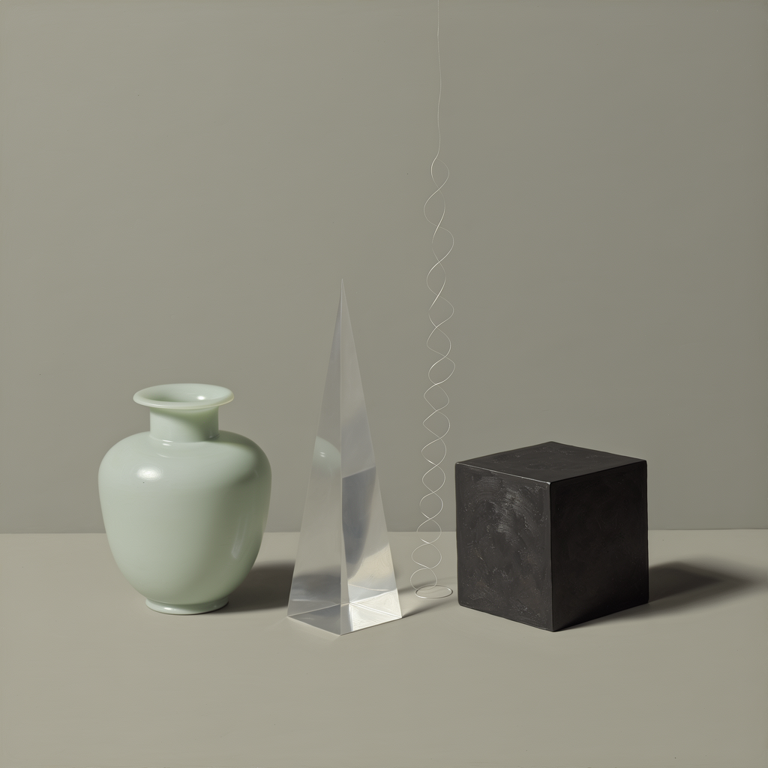

{'path': '/content/drive/MyDrive/FluxFlowMorphArt/science_path_prompt_only_chimera/science_path_prompt_only_chimera_0019_20260804T221412Z/trials/20260804T221545Z_02_physics_2059819972/trial.png', 'seed': 2059819972, 'prompt_index': 1}


In [6]:
import gc
import os
import random
import shutil
from huggingface_hub import hf_hub_download
from IPython.display import Markdown, display
from PIL import Image, ImageFilter
from flowmorph_klein.lora import load_flux2_lora

try:
    import peft.tuners.lora.torchao as peft_torchao_dispatch
except ImportError:
    peft_torchao_dispatch = None
else:
    peft_torchao_dispatch.is_torchao_available = lambda: False

downloaded_lora = Path(hf_hub_download(
    repo_id=LORA_SOURCE,
    filename=LORA_WEIGHT_NAME,
    revision=LORA_REVISION,
    cache_dir=HF_CACHE_DIR,
))
lora_stage_directory = Path(HF_CACHE_DIR) / "flowmorph_lora_files" / LORA_REVISION[:12]
lora_stage_directory.mkdir(parents=True, exist_ok=True)
LOCAL_LORA_PATH = lora_stage_directory / LORA_WEIGHT_NAME
if not LOCAL_LORA_PATH.is_file():
    try:
        os.link(downloaded_lora.resolve(), LOCAL_LORA_PATH)
    except OSError:
        shutil.copy2(downloaded_lora, LOCAL_LORA_PATH)
if LOCAL_LORA_PATH.stat().st_size != downloaded_lora.stat().st_size:
    raise RuntimeError(f"Staged LoRA size mismatch at {LOCAL_LORA_PATH}")

def release_flux_pipeline():
    previous = globals().pop("FLUX_PIPE", None)
    globals().pop("FLUX_PIPE_LORA_SCALE", None)
    globals().pop("FLUX_PIPE_CPU_OFFLOAD", None)
    if previous is not None:
        maybe_free = getattr(previous, "maybe_free_model_hooks", None)
        if callable(maybe_free):
            maybe_free()
        del previous
        gc.collect()
        torch.cuda.empty_cache()

def load_flux_pipeline():
    pipeline = Flux2KleinPipeline.from_pretrained(
        MODEL_ID,
        revision=MODEL_REVISION,
        cache_dir=HF_CACHE_DIR,
        torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True,
    )
    report = load_flux2_lora(
        pipeline,
        str(LOCAL_LORA_PATH),
        adapter_name=LORA_ADAPTER_NAME,
        scale=IMAGE_LORA_SCALE,
        require_base_9b_provenance=False,
        allow_distilled_9b=True,
    )
    pipeline.fuse_lora(
        components=["transformer"],
        lora_scale=1.0,
        safe_fusing=True,
        adapter_names=[LORA_ADAPTER_NAME],
    )
    pipeline.unload_lora_weights()
    remaining = [
        name for name, _ in pipeline.transformer.named_parameters()
        if "lora_" in name.casefold() or ".lora" in name.casefold()
    ]
    if remaining:
        raise RuntimeError("LoRA fusion left runtime parameters: " + ", ".join(remaining[:5]))
    if BASE_PIPELINE_CPU_OFFLOAD:
        pipeline.enable_model_cpu_offload()
    else:
        pipeline.to("cuda")
    pipeline.vae.enable_slicing()
    pipeline.vae.enable_tiling()
    return pipeline, report

pipeline_contract_changed = (
    "FLUX_PIPE" in globals()
    and (
        globals().get("FLUX_PIPE_LORA_SCALE") != float(IMAGE_LORA_SCALE)
        or globals().get("FLUX_PIPE_CPU_OFFLOAD") != bool(BASE_PIPELINE_CPU_OFFLOAD)
    )
)
if pipeline_contract_changed:
    print("Base pipeline LoRA/residency setting changed; rebuilding it.")
    release_flux_pipeline()
if "FLUX_PIPE" not in globals():
    FLUX_PIPE, LORA_REPORT = load_flux_pipeline()
    FLUX_PIPE_LORA_SCALE = float(IMAGE_LORA_SCALE)
    FLUX_PIPE_CPU_OFFLOAD = bool(BASE_PIPELINE_CPU_OFFLOAD)
    residency = "CPU-offloaded" if FLUX_PIPE_CPU_OFFLOAD else "GPU-resident"
    print(f"Loaded a fused-LoRA base pipeline ({residency}).")
else:
    residency = "CPU-offloaded" if FLUX_PIPE_CPU_OFFLOAD else "GPU-resident"
    print(f"Reusing the fused-LoRA base pipeline ({residency}).")


FLUX_PROMPT_TOKENIZER = FLUX_PIPE.tokenizer

def flux_prompt_token_count(prompt):
    messages = [{"role": "user", "content": prompt}]
    templated = FLUX_PROMPT_TOKENIZER.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    encoded = FLUX_PROMPT_TOKENIZER(
        templated,
        add_special_tokens=False,
        truncation=False,
    )
    return len(encoded["input_ids"])

def validate_flux_prompt_length(prompt, label="Prompt"):
    token_count = flux_prompt_token_count(prompt)
    if token_count > FLUX_PROMPT_MAX_SEQUENCE_LENGTH:
        raise ValueError(
            f"{label} tokenizes to {token_count} tokens after the FLUX chat "
            f"template; maximum is {FLUX_PROMPT_MAX_SEQUENCE_LENGTH}"
        )
    return token_count

if RUN_TRIAL_KEYFRAME:
    system_random = random.SystemRandom()
    trial_index = (
        TRIAL_KEYFRAME_INDEX
        if TRIAL_KEYFRAME_INDEX is not None
        else system_random.randrange(len(ACTIVE_BASE_STAGES))
    )
    if not 0 <= trial_index < len(ACTIVE_BASE_STAGES):
        raise IndexError("TRIAL_KEYFRAME_INDEX is outside the active anchor range")
    trial_seed = TRIAL_SEED if TRIAL_SEED is not None else system_random.randrange(2**31)
    trial_stage = ACTIVE_BASE_STAGES[trial_index]
    validate_flux_prompt_length(trial_stage["prompt"], "Trial anchor prompt")
    trial_result = FLUX_PIPE(
        prompt=trial_stage["prompt"],
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
        num_inference_steps=IMAGE_INFERENCE_STEPS,
        guidance_scale=IMAGE_GUIDANCE_SCALE,
        generator=torch.Generator(device="cuda").manual_seed(trial_seed),
        output_type="pil",
        max_sequence_length=FLUX_PROMPT_MAX_SEQUENCE_LENGTH,
    )
    trial_image = trial_result.images[0].convert("RGB")
    trial_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    trial_directory = RUN_DIRECTORY / "trials" / f"{trial_stamp}_{trial_stage['id']}_{trial_seed}"
    trial_directory.mkdir(parents=True, exist_ok=False)
    trial_path = trial_directory / "trial.png"
    trial_image.save(trial_path)
    (trial_directory / "settings.json").write_text(json.dumps({
        "stage": trial_stage,
        "seed": trial_seed,
        "lora_scale": IMAGE_LORA_SCALE,
        "guidance_scale": IMAGE_GUIDANCE_SCALE,
        "inference_steps": IMAGE_INFERENCE_STEPS,
        "size": [IMAGE_WIDTH, IMAGE_HEIGHT],
    }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
    preview = trial_image.copy()
    preview.thumbnail((TRIAL_DISPLAY_MAX_WIDTH, TRIAL_DISPLAY_MAX_WIDTH))
    display(Markdown(f"### Trial anchor: `{trial_stage['id']}`"))
    display(preview)
    print({"path": str(trial_path), "seed": trial_seed, "prompt_index": trial_index})
    del trial_result, trial_image, preview
else:
    print("Trial skipped.")


## 7. Generate prompt-only cyclic anchor paintings

The first anchor is ordinary text-to-image.  For every later anchor, the
original recursive-vision method blurs the previous painting, blends it into
a warm neutral field, adds faint deterministic monochrome grain, and passes
that PIL image directly to FLUX through `image=`.  This keeps broad continuity
without manually replacing the pipeline's native noise or sigma initialization.
Anchors are necessarily generated one at a time because each uses the preceding
painting; automatic batch learning is therefore performed on the first actual
CHIMERA midpoint render and retained across subsequent gaps.


In [ ]:
from flowmorph_klein.art_loop import make_soft_reference

BASE_DIRECTORY = RUN_DIRECTORY / "base_frames"
REFERENCE_DIRECTORY = BASE_DIRECTORY / "soft_references"
BASE_MANIFEST_PATH = RUN_DIRECTORY / "metadata" / "base_manifest.json"
BASE_RECORDS = []

def generate_prompt_anchor(prompt, seed, reference=None):
    validate_flux_prompt_length(prompt, "Anchor generation prompt")
    kwargs = {
        "prompt": prompt,
        "height": IMAGE_HEIGHT,
        "width": IMAGE_WIDTH,
        "num_inference_steps": IMAGE_INFERENCE_STEPS,
        "guidance_scale": IMAGE_GUIDANCE_SCALE,
        "generator": torch.Generator(device="cuda").manual_seed(seed),
        "output_type": "pil",
        "max_sequence_length": FLUX_PROMPT_MAX_SEQUENCE_LENGTH,
    }
    generation_mode = "text_to_image"
    if reference is not None:
        kwargs["image"] = reference
        generation_mode = "native_pipeline_image_conditioning"
    result = FLUX_PIPE(**kwargs)
    if not result.images:
        raise RuntimeError("FLUX returned no anchor image")
    return result.images[0].convert("RGB"), generation_mode

if not REGENERATE_BASE_FRAMES and BASE_MANIFEST_PATH.is_file():
    BASE_RECORDS = json.loads(
        BASE_MANIFEST_PATH.read_text(encoding="utf-8")
    )["records"]
    missing = [
        item["path"]
        for item in BASE_RECORDS
        if not Path(item["path"]).is_file()
    ]
    if missing:
        raise FileNotFoundError(
            "Missing resumed anchor images: " + ", ".join(missing)
        )
    resumed_contract = [
        (record["uid"], record["science"], record["prompt"])
        for record in BASE_RECORDS
    ]
    current_contract = [
        (f"base_{index:03d}", stage["science"], stage["prompt"])
        for index, stage in enumerate(ACTIVE_BASE_STAGES)
    ]
    if resumed_contract != current_contract:
        raise RuntimeError(
            "Editable anchor prompts differ from the saved anchors. "
            "Regenerate or resume the matching run."
        )
    print(f"Loaded {len(BASE_RECORDS)} existing anchor records.")
else:
    BASE_DIRECTORY.mkdir(parents=True, exist_ok=True)
    previous = None
    for index, stage in enumerate(ACTIVE_BASE_STAGES):
        seed = BASE_SEED + index
        reference = None
        reference_path = None
        if previous is not None and BASE_CONTINUITY_ENABLED:
            reference = make_soft_reference(
                previous,
                reference_blend=BASE_REFERENCE_STRENGTH,
                blur_radius=BASE_REFERENCE_BLUR,
                grain_strength=BASE_REFERENCE_GRAIN_STRENGTH,
                grain_seed=seed,
                background_rgb=REFERENCE_BACKGROUND,
            )
            if SAVE_SOFT_REFERENCES:
                REFERENCE_DIRECTORY.mkdir(parents=True, exist_ok=True)
                reference_path = (
                    REFERENCE_DIRECTORY / f"reference_{index:03d}.png"
                )
                reference.save(reference_path, format="PNG", compress_level=4)
        image, generation_mode = generate_prompt_anchor(
            stage["prompt"],
            seed,
            reference=reference,
        )
        output_path = BASE_DIRECTORY / f"{index:03d}_{stage['id']}.png"
        image.save(output_path, format="PNG", compress_level=4)
        record = {
            "uid": f"base_{index:03d}",
            "kind": "base",
            "round": 0,
            "science": stage["science"],
            "prompt": stage["prompt"],
            "generation_prompt": stage["prompt"],
            "generation_prompt_token_count": validate_flux_prompt_length(
                stage["prompt"],
                "Saved anchor prompt",
            ),
            "seed": seed,
            "path": str(output_path),
            "soft_reference_path": (
                str(reference_path) if reference_path else None
            ),
            "base_continuity_used": reference is not None,
            "base_reference_source": "original_recursive_vision_soft_reference",
            "base_reference_strength": BASE_REFERENCE_STRENGTH,
            "base_reference_blur": BASE_REFERENCE_BLUR,
            "base_reference_grain_strength": BASE_REFERENCE_GRAIN_STRENGTH,
            "reference_background": list(REFERENCE_BACKGROUND),
            "generation_mode": generation_mode,
        }
        BASE_RECORDS.append(record)
        BASE_MANIFEST_PATH.write_text(json.dumps({
            "project": PROJECT_NAME,
            "complete": len(BASE_RECORDS) == len(ACTIVE_BASE_STAGES),
            "records": BASE_RECORDS,
        }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
        if previous is not None:
            previous.close()
        previous = image.copy()
        image.close()
        if reference is not None:
            reference.close()
        print(
            f"Anchor {index + 1}/{len(ACTIVE_BASE_STAGES)} saved: "
            f"{output_path.name}"
        )
    if previous is not None:
        previous.close()

if len(BASE_RECORDS) != len(ACTIVE_BASE_STAGES):
    raise RuntimeError("The anchor manifest is incomplete.")
print(f"Prepared {len(BASE_RECORDS)} cyclic anchors in {BASE_DIRECTORY}")


  0%|          | 0/50 [00:00<?, ?it/s]

Anchor 1/12 saved: 000_01_astronomy.png


  0%|          | 0/50 [00:00<?, ?it/s]

Anchor 2/12 saved: 001_02_physics.png


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

Anchor 6/12 saved: 005_06_botany.png


  0%|          | 0/50 [00:00<?, ?it/s]

Anchor 7/12 saved: 006_07_genetics_cell.png


  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
from flowmorph_klein.visualization import make_contact_sheet

base_contact_sheet_path = RUN_DIRECTORY / "previews" / "base_contact_sheet.png"
base_images = [Image.open(item["path"]).convert("RGB") for item in BASE_RECORDS]
make_contact_sheet(
    base_images,
    base_contact_sheet_path,
    columns=min(CONTACT_SHEET_COLUMNS, len(base_images)),
    labels=[item["uid"] for item in BASE_RECORDS],
)
for image in base_images:
    image.close()
base_preview = Image.open(base_contact_sheet_path).convert("RGB")
base_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
display(Markdown("### Anchor paintings — compact contact sheet"))
display(base_preview)
del base_preview, base_images
print("Full-resolution anchors and contact sheet:", BASE_DIRECTORY)

saved_reference_paths = [
    Path(item["soft_reference_path"])
    for item in BASE_RECORDS
    if item.get("soft_reference_path") and Path(item["soft_reference_path"]).is_file()
]
if saved_reference_paths:
    reference_contact_sheet_path = (
        RUN_DIRECTORY / "previews" / "anchor_soft_reference_contact_sheet.png"
    )
    reference_images = []
    for path in saved_reference_paths:
        with Image.open(path) as opened:
            thumbnail = opened.convert("RGB")
            thumbnail.thumbnail((192, 192))
            reference_images.append(thumbnail)
    make_contact_sheet(
        reference_images,
        reference_contact_sheet_path,
        columns=min(CONTACT_SHEET_COLUMNS, len(reference_images)),
        labels=[path.stem for path in saved_reference_paths],
    )
    for image in reference_images:
        image.close()
    reference_preview = Image.open(reference_contact_sheet_path).convert("RGB")
    reference_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown("### Blurred/grained anchor initialization images"))
    display(reference_preview)
    reference_preview.close()
    print("Full-resolution anchor initialization images:", saved_reference_paths[0].parent)


## 8. Define CHIMERA Semantic Anchor Prompting (SAP)

Each request receives the two actual endpoint paintings, their authored
prompts, and their sciences. It returns one image-aware intermediate prompt
for the whole pair. The authored endpoint prompts are never rewritten: they
condition inversion and the continuous alpha interpolation, while the single
intermediate prompt supplies SAP during the early denoising steps. This avoids
per-frame prompt jitter and protects sparse scenes from invented inventory.
Padding-masked FLUX embeddings produce two diagnostic cosines plus an
endpoint-relative bridge score. The `0.45` gate therefore remains meaningful
on Qwen's scale and triggers bounded VLM re-queries when necessary.


In [ ]:
import base64
import hashlib
import io
import time
from pydantic import BaseModel, Field, ValidationError

if CHIMERA_INTERMEDIATE_PROMPT_MODE != "openai_per_pair":
    raise ValueError("CHIMERA_INTERMEDIATE_PROMPT_MODE currently supports openai_per_pair")

class ChimeraIntermediateProposal(BaseModel):
    science_connection: str = Field(min_length=20, max_length=800)
    visual_correspondence: str = Field(min_length=20, max_length=1200)
    intermediate_prompt: str = Field(min_length=120, max_length=1800)

CHIMERA_SAP_SYSTEM_PROMPT = f"""
Role: You are an art director writing one stable Semantic Anchor Prompt for a
CHIMERA image sequence rendered by FLUX.2 Klein with the {LORA_TRIGGER} LoRA.

Inspect both attached paintings and their authored generation prompts. Return
one literal intermediate_prompt describing a plausible visual midpoint. It is
used as the shared semantic anchor for every rendered position in this pair.

Requirements for intermediate_prompt:
- Begin exactly with "{LORA_TRIGGER}," and contain that trigger exactly once.
- Preserve the actual shared style, restraint, object density, palette, lighting,
  support geometry, and negative space visible in the two paintings and stated
  in their authored prompts. Never substitute a stock historical style.
- Map major forms by position, silhouette, scale, orientation, and material.
  Transform paired forms rather than listing the full inventory of both sides.
- Do not introduce an object unless it is visible or named in at least one
  endpoint, or is the direct hybrid counterpart of two mapped endpoint forms.
- Keep sparse scenes sparse. Preserve generous negative space and never fill it
  merely to make the composition more elaborate.
- Be a standalone literal image description, never an editing instruction.
- Fit within {FLUX_PROMPT_MAX_SEQUENCE_LENGTH} tokens after FLUX's chat template.

The result must be genuinely between the supplied paintings, not a third scene.
The authored endpoint prompts are immutable and are not fields in your output.

Do not use production words such as source image, target image, endpoint,
frame, interpolation, morph, transition, halfway, retain, preserve, unchanged,
or same. Output only the structured fields.
""".strip()

FORBIDDEN_CHIMERA_PROMPT_TERMS = (
    "source image", "target image", "endpoint", "frame", "interpolation",
    "morph", "transition", "halfway", "retain", "preserve", "unchanged",
)

def image_data_url(path):
    with Image.open(path) as opened:
        image = opened.convert("RGB")
        image.thumbnail((VISION_IMAGE_MAX_SIDE, VISION_IMAGE_MAX_SIDE))
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG", quality=VISION_JPEG_QUALITY, optimize=True)
    encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
    return f"data:image/jpeg;base64,{encoded}"

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def validate_chimera_prompt(prompt, label):
    clean = " ".join(prompt.split())
    if not clean.startswith(f"{LORA_TRIGGER},"):
        raise ValueError(f"{label} must begin exactly with {LORA_TRIGGER},")
    if clean.casefold().count(LORA_TRIGGER.casefold()) != 1:
        raise ValueError(f"{label} must contain the LoRA trigger exactly once")
    found = [
        term for term in FORBIDDEN_CHIMERA_PROMPT_TERMS
        if re.search(rf"\b{re.escape(term)}\b", clean, re.I)
    ]
    if found:
        raise ValueError(f"{label} contains production terms: {', '.join(found)}")
    validate_flux_prompt_length(clean, label)
    return clean

def validate_chimera_proposal(proposal):
    proposal.intermediate_prompt = validate_chimera_prompt(
        proposal.intermediate_prompt, "Intermediate prompt"
    )
    return proposal

def extract_parsed_proposal(response):
    parsed = getattr(response, "output_parsed", None)
    if parsed is not None:
        return parsed
    refusals = []
    for output in response.output:
        if output.type != "message":
            continue
        for item in output.content:
            if item.type == "refusal":
                refusals.append(item.refusal)
            elif getattr(item, "parsed", None) is not None:
                return item.parsed
    if refusals:
        raise RuntimeError("OpenAI refused the intermediate-prompt request: " + " | ".join(refusals))
    raise RuntimeError("OpenAI response contained no parsed intermediate proposal")

def chimera_request_fingerprint(left, right):
    contract = {
        "model": OPENAI_MODEL,
        "reasoning_effort": OPENAI_REASONING_EFFORT,
        "image_detail": OPENAI_IMAGE_DETAIL,
        "prompt_mode": CHIMERA_INTERMEDIATE_PROMPT_MODE,
        "system_prompt": CHIMERA_SAP_SYSTEM_PROMPT,
        "left_uid": left["uid"],
        "left_science": left["science"],
        "left_prompt": left["prompt"],
        "left_image_sha256": file_sha256(left["path"]),
        "right_uid": right["uid"],
        "right_science": right["science"],
        "right_prompt": right["prompt"],
        "right_image_sha256": file_sha256(right["path"]),
    }
    serialized = json.dumps(contract, sort_keys=True, ensure_ascii=False).encode("utf-8")
    return hashlib.sha256(serialized).hexdigest(), contract

def propose_chimera_intermediate(left, right, reliability_feedback=None):
    feedback = ""
    if reliability_feedback:
        feedback = (
            "\n\nThe prior intermediate prompt failed the embedding reliability gate. "
            f"{reliability_feedback} Rewrite it around a clearer concrete "
            "correspondence already present in the two paintings."
        )
    request_text = f"""
    Painting A sciences: {left['science']}
    Painting A authored FLUX prompt (verbatim):
    {left['prompt']}

    Painting B sciences: {right['science']}
    Painting B authored FLUX prompt (verbatim):
    {right['prompt']}

    Treat each authored prompt and its correspondingly labelled attached image
    as one endpoint description. Inspect both prompt-image pairs and return one
    intermediate proposal.
    {feedback}
    """.strip()
    correction = ""
    last_error = None
    for attempt in range(1, OPENAI_MAX_ATTEMPTS + 1):
        try:
            response = OPENAI_CLIENT.responses.parse(
                model=OPENAI_MODEL,
                reasoning={"effort": OPENAI_REASONING_EFFORT},
                store=False,
                max_output_tokens=OPENAI_MAX_OUTPUT_TOKENS,
                input=[
                    {"role": "system", "content": CHIMERA_SAP_SYSTEM_PROMPT},
                    {
                        "role": "user",
                        "content": [
                            {"type": "input_text", "text": request_text + correction},
                            {"type": "input_text", "text": "Painting A image, paired with the verbatim Painting A prompt above:"},
                            {"type": "input_image", "image_url": image_data_url(left["path"]), "detail": OPENAI_IMAGE_DETAIL},
                            {"type": "input_text", "text": "Painting B image, paired with the verbatim Painting B prompt above:"},
                            {"type": "input_image", "image_url": image_data_url(right["path"]), "detail": OPENAI_IMAGE_DETAIL},
                        ],
                    },
                ],
                text_format=ChimeraIntermediateProposal,
            )
            proposal = validate_chimera_proposal(extract_parsed_proposal(response))
            return proposal, response
        except (ValidationError, json.JSONDecodeError, ValueError) as error:
            last_error = error
            correction = (
                f"\n\nThe prior response failed validation: {error}. Return shorter, "
                "complete structured fields that satisfy every prompt rule."
            )
            if attempt < OPENAI_MAX_ATTEMPTS:
                time.sleep(min(2 ** (attempt - 1), 4))
                continue
            raise RuntimeError(f"Intermediate prompt failed after {attempt} attempts") from error
    raise RuntimeError(f"Intermediate prompt generation failed: {last_error}")

print("CHIMERA one-image-aware-intermediate-prompt-per-pair contract ready.")


## 9. One-model CHIMERA session and optional one-gap quality gate

The standalone fused anchor generator is released.  One unfused LoRA-aware
FLUX.2 model is then retained for all reverse Euler inversions and CHIMERA
denoising calls.  The gate renders a single cyclic gap before the full run.


In [ ]:
import gc
import matplotlib.pyplot as plt
import numpy as np
import torch
from concurrent.futures import ThreadPoolExecutor
from flowmorph_klein.chimera import (
    ChimeraConfig,
    ChimeraFlux2Session,
    LTM_CALIBRATION_VERSION,
    LTM_TIMESTEP_SMOOTHING_RADIUS,
    LTMCalibration,
    center_weighted_alpha_schedule,
    prompt_anchor_reliability,
    select_flux_feature_groups,
)
from flowmorph_klein.cli import select_hardware_profile
from flowmorph_klein.config import ProjectTemplateConfig, load_config, resolve_config
from flowmorph_klein.pipeline import FlowMorphRunner
from flowmorph_klein.temporal_tone import TemporalToneConfig, stabilize_cyclic_tone

def validate_chimera_runner_contract(config):
    for name, value in (("width", config.input.width), ("height", config.input.height)):
        if not 256 <= value <= 2048 or value % 16 != 0:
            raise ValueError(f"input.{name} must be 256-2048 and divisible by 16")
    if config.flowmorph.scheduler_points != CHIMERA_DENOISING_STEPS:
        raise ValueError("Runner schedule must match CHIMERA_DENOISING_STEPS")

ProjectTemplateConfig._validate_full_shape_contract = validate_chimera_runner_contract

BASE_PROMPT_TOKEN_COUNTS = {
    record["uid"]: validate_flux_prompt_length(record["prompt"], f"{record['uid']} prompt")
    for record in BASE_RECORDS
}
print({"anchor_prompt_token_counts": BASE_PROMPT_TOKEN_COUNTS})
release_flux_pipeline()

def usage_payload(response):
    usage = getattr(response, "usage", None)
    if usage is None:
        return None
    return usage.model_dump(mode="json") if hasattr(usage, "model_dump") else str(usage)

def stable_fingerprint(payload):
    serialized = json.dumps(payload, sort_keys=True, ensure_ascii=False).encode("utf-8")
    return hashlib.sha256(serialized).hexdigest()

def load_or_create_intermediate(left, right, round_number, gap_index, path):
    request_fingerprint, request_contract = chimera_request_fingerprint(left, right)
    if REUSE_EXISTING_MIDPOINTS and path.is_file():
        saved = json.loads(path.read_text(encoding="utf-8"))
        if saved.get("request_fingerprint") == request_fingerprint:
            proposal = validate_chimera_proposal(
                ChimeraIntermediateProposal.model_validate(saved["proposal"])
            )
            return {
                "left": left,
                "right": right,
                "round": round_number,
                "gap_index": gap_index,
                "proposal_path": path,
                "proposal": proposal,
                "response_id": saved.get("openai_response_id"),
                "usage": saved.get("usage"),
                "request_fingerprint": request_fingerprint,
                "request_contract": request_contract,
                "reliability": saved.get("reliability"),
                "requeries": int(saved.get("requeries", 0)),
            }
    proposal, response = propose_chimera_intermediate(left, right)
    return {
        "left": left,
        "right": right,
        "round": round_number,
        "gap_index": gap_index,
        "proposal_path": path,
        "proposal": proposal,
        "response_id": response.id,
        "usage": usage_payload(response),
        "request_fingerprint": request_fingerprint,
        "request_contract": request_contract,
        "reliability": None,
        "requeries": 0,
    }

def proposal_prompts(job):
    proposal = job["proposal"]
    return (job["left"]["prompt"], proposal.intermediate_prompt, job["right"]["prompt"])

def print_pair_prompt_plan(job, label):
    print(f"\n=== {label}: {job['left']['uid']} -> {job['right']['uid']} ===")
    print(f"SOURCE IMAGE: {job['left']['path']}")
    print("SOURCE AUTHORED PROMPT:")
    print(job["left"]["prompt"])
    print("OPENAI INTERMEDIATE / SAP PROMPT:")
    print(job["proposal"].intermediate_prompt)
    print(f"TARGET IMAGE: {job['right']['path']}")
    print("TARGET AUTHORED PROMPT:")
    print(job["right"]["prompt"])
    print("SAP RELIABILITY:", job.get("reliability"))

def save_intermediate_job(job):
    path = Path(job["proposal_path"])
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps({
        "round": job["round"],
        "gap_index": job["gap_index"],
        "left_uid": job["left"]["uid"],
        "right_uid": job["right"]["uid"],
        "request_fingerprint": job["request_fingerprint"],
        "request_contract": job["request_contract"],
        "proposal": job["proposal"].model_dump(mode="json"),
        "reliability": job["reliability"],
        "threshold": CHIMERA_ANCHOR_RELIABILITY_THRESHOLD,
        "requeries": job["requeries"],
        "openai_model": OPENAI_MODEL,
        "openai_response_id": job["response_id"],
        "usage": job["usage"],
    }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

CHIMERA_ROOT = RUN_DIRECTORY / "chimera_sequence"
CHIMERA_SESSION_DIRECTORY = CHIMERA_ROOT / "session"
CHIMERA_ASSET_ROOT = CHIMERA_ROOT / "encoded_inputs"
for directory in (CHIMERA_ROOT, CHIMERA_SESSION_DIRECTORY, CHIMERA_ASSET_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

bootstrap_left = BASE_RECORDS[0]
bootstrap_right = BASE_RECORDS[1]
bootstrap_schedule = [bootstrap_left["prompt"], bootstrap_left["prompt"], bootstrap_right["prompt"]]
session_overrides = {
    "run_mode": "experimental",
    "project.name": f"{PROJECT_NAME}_chimera_session",
    "model.id": MODEL_ID,
    "model.revision": MODEL_REVISION,
    "lora.source": str(LOCAL_LORA_PATH),
    "lora.revision": None,
    "lora.weight_name": LOCAL_LORA_PATH.name,
    "lora.adapter_name": LORA_ADAPTER_NAME,
    "lora.fit_scale": CHIMERA_LORA_SCALE,
    "lora.render_scale": CHIMERA_LORA_SCALE,
    "lora.require_base_9b_compatibility": False,
    "lora.allow_distilled_9b": True,
    "input.source_image": str(bootstrap_left["path"]),
    "input.target_image": str(bootstrap_right["path"]),
    "input.source_prompt": bootstrap_left["prompt"],
    "input.target_prompt": bootstrap_right["prompt"],
    "input.bridge_prompt": None,
    "input.bridge_prompts": bootstrap_schedule,
    "input.width": IMAGE_WIDTH,
    "input.height": IMAGE_HEIGHT,
    "flowmorph.scheduler_points": CHIMERA_DENOISING_STEPS,
    "flowmorph.start_timestep_index": 0,
    "flowmorph.optimization_steps_source": 1,
    "flowmorph.optimization_steps_target": 1,
    "flowmorph.frame_count": len(bootstrap_schedule),
    "flowmorph.render_indices": [0, CHIMERA_DENOISING_STEPS // 2, CHIMERA_DENOISING_STEPS - 1],
    "flowmorph.render_conditioning_mode": "prompt_schedule",
    "guidance.scale": CHIMERA_GUIDANCE_SCALE,
    "reproducibility.seed": BASE_SEED,
    "paths.input_root": str(RUN_DIRECTORY),
    "paths.work_root": str(Path(LOCAL_ASSET_ROOT) / PROJECT_NAME / "chimera_work"),
    "paths.result_root": str(CHIMERA_ROOT),
    "paths.hf_cache": HF_CACHE_DIR,
    "paths.drive_root": None,
    "output.save_contact_sheet": False,
    "output.save_webp": False,
    "output.save_gif": False,
    "output.save_mp4": False,
    "output.create_zip": True,
}
session_template = load_config(CONFIG_PATH, overrides=session_overrides)
session_profile = select_hardware_profile(PROFILE if PROFILE != "auto" else session_template.model.profile)
session_config = resolve_config(session_template, selected_profile=session_profile, check_input_files=True)
session_resume = RESUME_CHIMERA_SEQUENCE and (CHIMERA_SESSION_DIRECTORY / "run_manifest.json").is_file()
# Defensive final handoff: no base-pipeline CUDA weights may coexist with
# the separately loaded CHIMERA runner used for inversion and midframes.
release_flux_pipeline()
if "FLUX_PIPE" in globals():
    raise RuntimeError("Base FLUX pipeline survived the CHIMERA handoff")
if torch.cuda.is_available():
    print({"cuda_allocated_gib_before_chimera_load": round(torch.cuda.memory_allocated() / 1024**3, 3)})
CHIMERA_RUNNER = FlowMorphRunner.from_config(session_config, run_directory=CHIMERA_SESSION_DIRECTORY)
CHIMERA_RUNNER.prepare(resume=session_resume)
CHIMERA_CONFIG = ChimeraConfig(
    inversion_steps=CHIMERA_INVERSION_STEPS,
    denoising_steps=CHIMERA_DENOISING_STEPS,
    aci_weight=CHIMERA_ACI_WEIGHT,
    sap_active_ratio=CHIMERA_SAP_ACTIVE_RATIO,
    anchor_max_tokens=CHIMERA_ANCHOR_MAX_TOKENS,
    anchor_reliability_threshold=CHIMERA_ANCHOR_RELIABILITY_THRESHOLD,
    ltm_mode=CHIMERA_LTM_MODE,
    ltm_bands=CHIMERA_LTM_BANDS,
    ltm_channel_chunk_size=CHIMERA_LTM_CHANNEL_CHUNK_SIZE,
    cache_stride=CHIMERA_CACHE_STRIDE,
    cache_storage=CHIMERA_CACHE_STORAGE,
    velocity_smoothing_strength=CHIMERA_VELOCITY_SMOOTHING_STRENGTH,
    render_batch_size=CHIMERA_RENDER_BATCH_SIZE,
    render_batch_max=CHIMERA_RENDER_BATCH_MAX,
    auto_render_batch_size=CHIMERA_AUTO_RENDER_BATCH_SIZE,
    batch_memory_reserve_fraction=CHIMERA_BATCH_MEMORY_RESERVE_FRACTION,
    batch_memory_reserve_gib=CHIMERA_BATCH_MEMORY_RESERVE_GIB,
    batch_estimate_overhead=CHIMERA_BATCH_ESTIMATE_OVERHEAD,
    decode_batch_size=CHIMERA_DECODE_BATCH_SIZE,
    guidance_scale=CHIMERA_GUIDANCE_SCALE,
    lora_scale=CHIMERA_LORA_SCALE,
    conditioning_interpolation=CHIMERA_CONDITIONING_INTERPOLATION,
    cfg_execution=CHIMERA_CFG_EXECUTION,
    oom_backoff=CHIMERA_BATCH_OOM_BACKOFF,
)
CHIMERA_SESSION = ChimeraFlux2Session(CHIMERA_RUNNER, config=CHIMERA_CONFIG)
IMAGE_ASSET_CACHE, PROMPT_CONDITIONING_CACHE = CHIMERA_SESSION.seed_prepared_assets(
    bootstrap_left["uid"], bootstrap_right["uid"]
)

# The paper's LTM prototypes are dataset-level, not pair-specific.  We
# approximate that contract with an evenly spaced subset of this run's
# independently generated anchors, persist it on Drive, and reuse it for
# every pair.  Calibration retains only 16-value spectra, never full caches.
CHIMERA_LTM_CALIBRATION_PATH = (
    RUN_DIRECTORY / "metadata" / "chimera_ltm_calibration.json"
)
CHIMERA_LTM_CALIBRATION = None
if CHIMERA_LTM_MODE == "fft":
    calibration_count = min(CHIMERA_LTM_CALIBRATION_ANCHORS, len(BASE_RECORDS))
    if calibration_count < 1:
        raise RuntimeError("FFT LTM calibration requires at least one unique anchor")
    calibration_indices = (
        [0]
        if calibration_count == 1
        else [
            round(index * (len(BASE_RECORDS) - 1) / (calibration_count - 1))
            for index in range(calibration_count)
        ]
    )
    if len(set(calibration_indices)) != calibration_count:
        raise RuntimeError("FFT LTM anchor selection unexpectedly produced duplicates")
    calibration_records = [BASE_RECORDS[index] for index in calibration_indices]
    calibration_images = {
        record["uid"]: (
            record["path"],
            CHIMERA_ASSET_ROOT / f"{record['uid']}.png",
        )
        for record in calibration_records
        if record["uid"] not in IMAGE_ASSET_CACHE
    }
    calibration_prompts = [
        record["prompt"]
        for record in calibration_records
        if record["prompt"] not in PROMPT_CONDITIONING_CACHE
    ]
    if calibration_images or calibration_prompts:
        encoded_prompts, encoded_images = CHIMERA_SESSION.encode_missing_assets(
            prompts=list(dict.fromkeys(calibration_prompts)),
            images=calibration_images,
        )
        PROMPT_CONDITIONING_CACHE.update(encoded_prompts)
        IMAGE_ASSET_CACHE.update(encoded_images)

    calibration_contract = {
        "method": "CHIMERA FLUX LTM normalized frequency prototypes v2",
        "calibration_version": LTM_CALIBRATION_VERSION,
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
        "lora_sha256": file_sha256(LOCAL_LORA_PATH),
        "lora_scale": CHIMERA_LORA_SCALE,
        "width": IMAGE_WIDTH,
        "height": IMAGE_HEIGHT,
        "steps": CHIMERA_DENOISING_STEPS,
        "bands": CHIMERA_LTM_BANDS,
        "descriptor_normalized": True,
        "timestep_descriptor": "conditional_velocity",
        "timestep_smoothing_radius": LTM_TIMESTEP_SMOOTHING_RADIUS,
        "mapping_strategy": "monotonic FFT with fixed coarse-to-fine fallback",
        "requested_anchor_count": CHIMERA_LTM_CALIBRATION_ANCHORS,
        "unique_anchor_count": calibration_count,
        "feature_groups": [
            group.label
            for group in select_flux_feature_groups(
                CHIMERA_RUNNER.pipeline.transformer
            )
        ],
        "anchors": [
            {
                "uid": record["uid"],
                "image_sha256": file_sha256(record["path"]),
                "prompt": record["prompt"],
            }
            for record in calibration_records
        ],
    }
    calibration_contract_fingerprint = stable_fingerprint(calibration_contract)
    calibration_reused = False
    if REUSE_CHIMERA_LTM_CALIBRATION and CHIMERA_LTM_CALIBRATION_PATH.is_file():
        saved_calibration = json.loads(
            CHIMERA_LTM_CALIBRATION_PATH.read_text(encoding="utf-8")
        )
        if saved_calibration.get("contract_fingerprint") == calibration_contract_fingerprint:
            candidate = LTMCalibration.from_dict(saved_calibration["calibration"])
            if saved_calibration.get("calibration_fingerprint") != candidate.fingerprint:
                raise RuntimeError("Saved LTM calibration fingerprint is corrupt")
            CHIMERA_SESSION.set_ltm_calibration(candidate)
            CHIMERA_LTM_CALIBRATION = candidate
            calibration_reused = True

    if CHIMERA_LTM_CALIBRATION is None:
        print({
            "ltm_calibration": "running",
            "anchor_uids": [record["uid"] for record in calibration_records],
            "inversions": len(calibration_records),
            "bands": CHIMERA_LTM_BANDS,
        })
        CHIMERA_LTM_CALIBRATION = CHIMERA_SESSION.calibrate_ltm(tuple(
            (
                IMAGE_ASSET_CACHE[record["uid"]],
                PROMPT_CONDITIONING_CACHE[record["prompt"]],
            )
            for record in calibration_records
        ))
        CHIMERA_LTM_CALIBRATION_PATH.parent.mkdir(parents=True, exist_ok=True)
        CHIMERA_LTM_CALIBRATION_PATH.write_text(json.dumps({
            "contract_fingerprint": calibration_contract_fingerprint,
            "calibration_fingerprint": CHIMERA_LTM_CALIBRATION.fingerprint,
            "contract": calibration_contract,
            "calibration": CHIMERA_LTM_CALIBRATION.to_dict(),
        }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

    CHIMERA_LTM_FINGERPRINT = stable_fingerprint({
        "contract": calibration_contract_fingerprint,
        "calibration": CHIMERA_LTM_CALIBRATION.fingerprint,
    })
    CHIMERA_LTM_REPORT = {
        "mode": "fft",
        "reused": calibration_reused,
        "path": str(CHIMERA_LTM_CALIBRATION_PATH),
        "sample_count": CHIMERA_LTM_CALIBRATION.sample_count,
        "version": CHIMERA_LTM_CALIBRATION.version,
        "mapping_strategy": CHIMERA_LTM_CALIBRATION.mapping_strategy,
        "fallback_reason": CHIMERA_LTM_CALIBRATION.fallback_reason,
        "mapping_report": CHIMERA_LTM_CALIBRATION.mapping_report,
        "independent_mapping_report": CHIMERA_LTM_CALIBRATION.independent_mapping_report,
        "mapping": list(CHIMERA_LTM_CALIBRATION.mapping),
        "fingerprint": CHIMERA_LTM_FINGERPRINT,
    }
else:
    CHIMERA_LTM_FINGERPRINT = stable_fingerprint({
        "mode": "linear",
        "steps": CHIMERA_DENOISING_STEPS,
    })
    CHIMERA_LTM_REPORT = {
        "mode": "linear",
        "mapping": "fixed early/middle/late thirds",
        "fingerprint": CHIMERA_LTM_FINGERPRINT,
    }

print({
    "model_loads": 1,
    "backward_probes": 0,
    "training_or_endpoint_optimization": False,
    "feature_groups": [group.label for group in select_flux_feature_groups(CHIMERA_RUNNER.pipeline.transformer)],
    "cache_storage": CHIMERA_CACHE_STORAGE,
    "cache_stride": CHIMERA_CACHE_STRIDE,
    "velocity_smoothing_strength": CHIMERA_VELOCITY_SMOOTHING_STRENGTH,
    "ltm": CHIMERA_LTM_REPORT,
    "adaptive_render_batch": CHIMERA_SESSION.render_batch_report,
})

def encode_prompt_values(prompts):
    missing = [prompt for prompt in dict.fromkeys(prompts) if prompt not in PROMPT_CONDITIONING_CACHE]
    if missing:
        encoded, _ = CHIMERA_SESSION.encode_missing_assets(prompts=missing, images={})
        PROMPT_CONDITIONING_CACHE.update(encoded)

def ensure_reliable_intermediate(job):
    encode_prompt_values(proposal_prompts(job))
    while True:
        proposal = job["proposal"]
        similarity_a, similarity_b, reliability = prompt_anchor_reliability(
            PROMPT_CONDITIONING_CACHE[proposal.intermediate_prompt],
            PROMPT_CONDITIONING_CACHE[job["left"]["prompt"]],
            PROMPT_CONDITIONING_CACHE[job["right"]["prompt"]],
        )
        job["reliability"] = {
            "anchor_to_a": similarity_a,
            "anchor_to_b": similarity_b,
            "minimum": reliability,
        }
        if reliability >= CHIMERA_ANCHOR_RELIABILITY_THRESHOLD:
            save_intermediate_job(job)
            return job
        if job["requeries"] >= CHIMERA_SAP_MAX_REQUERIES:
            raise RuntimeError(
                f"SAP reliability stayed at {reliability:.4f} below "
                f"{CHIMERA_ANCHOR_RELIABILITY_THRESHOLD:.4f} for "
                f"{job['left']['uid']} -> {job['right']['uid']}"
            )
        feedback = (
            f"anchor-to-A cosine={similarity_a:.4f}, anchor-to-B cosine={similarity_b:.4f}, "
            f"normalized bridge reliability={reliability:.4f}, "
            f"required reliability={CHIMERA_ANCHOR_RELIABILITY_THRESHOLD:.4f}."
        )
        proposal, response = propose_chimera_intermediate(job["left"], job["right"], feedback)
        job["proposal"] = proposal
        job["response_id"] = response.id
        job["usage"] = usage_payload(response)
        job["requeries"] += 1
        encode_prompt_values(proposal_prompts(job))

def render_chimera_job(job, alphas, output_paths):
    proposal = job["proposal"]
    source_cache, target_cache = CHIMERA_SESSION.invert_pair(
        pair_key=f"r{job['round']:02d}_g{job['gap_index']:04d}",
        source_asset=IMAGE_ASSET_CACHE[job["left"]["uid"]],
        target_asset=IMAGE_ASSET_CACHE[job["right"]["uid"]],
        source_conditioning=PROMPT_CONDITIONING_CACHE[job["left"]["prompt"]],
        target_conditioning=PROMPT_CONDITIONING_CACHE[job["right"]["prompt"]],
    )
    frames = CHIMERA_SESSION.render_pair(
        source_cache=source_cache,
        target_cache=target_cache,
        source_conditioning=PROMPT_CONDITIONING_CACHE[job["left"]["prompt"]],
        target_conditioning=PROMPT_CONDITIONING_CACHE[job["right"]["prompt"]],
        anchor_conditioning=PROMPT_CONDITIONING_CACHE[proposal.intermediate_prompt],
        alphas=alphas,
    )
    CHIMERA_SESSION.decode_frames_to_paths(frames, output_paths)
    cache_report = {
        "source_cache_mib": source_cache.storage_bytes / (1024 ** 2),
        "target_cache_mib": target_cache.storage_bytes / (1024 ** 2),
        "feature_groups": dict(source_cache.group_modules),
        "ltm_mode": CHIMERA_LTM_MODE,
        "ltm_mapping": (
            list(CHIMERA_LTM_CALIBRATION.mapping)
            if CHIMERA_LTM_CALIBRATION is not None
            else "fixed early/middle/late thirds"
        ),
        "ltm_fingerprint": CHIMERA_LTM_FINGERPRINT,
        "ltm_report": CHIMERA_LTM_REPORT,
        "velocity_smoothing_strength": CHIMERA_VELOCITY_SMOOTHING_STRENGTH,
        "conditioning_interpolation": CHIMERA_CONDITIONING_INTERPOLATION,
        "conditioning_diagnostics": list(CHIMERA_SESSION.conditioning_diagnostics_report),
        "render_batch": CHIMERA_SESSION.render_batch_report,
        "decode_batch_size": CHIMERA_SESSION.last_decode_batch_size,
    }
    del source_cache, target_cache, frames
    gc.collect()
    torch.cuda.empty_cache()
    return cache_report

if RUN_CHIMERA_ONE_GAP_TEST:
    test_index = CHIMERA_ONE_GAP_TEST_INDEX
    test_left = BASE_RECORDS[test_index]
    test_right = BASE_RECORDS[(test_index + 1) % len(BASE_RECORDS)]
    test_directory = RUN_DIRECTORY / "quality_gates" / "chimera_one_gap"
    test_directory.mkdir(parents=True, exist_ok=True)
    test_job = load_or_create_intermediate(test_left, test_right, 0, test_index, test_directory / "sap_intermediate.json")
    ensure_reliable_intermediate(test_job)
    print_pair_prompt_plan(test_job, "QUALITY-GATE PROMPT PLAN")
    missing_images = {
        record["uid"]: (record["path"], CHIMERA_ASSET_ROOT / f"{record['uid']}.png")
        for record in (test_left, test_right)
        if record["uid"] not in IMAGE_ASSET_CACHE
    }
    if missing_images:
        _, images = CHIMERA_SESSION.encode_missing_assets(prompts=[], images=missing_images)
        IMAGE_ASSET_CACHE.update(images)
    quality_midpoint_count = int(CHIMERA_ROUND_SPECS[0]["midpoint_count"])
    quality_alphas = list(center_weighted_alpha_schedule(
        quality_midpoint_count, strength=CHIMERA_ALPHA_WARP_STRENGTH
    ))
    test_paths = [
        test_directory / f"production_{index:02d}_alpha_{alpha:.6f}.png"
        for index, alpha in enumerate(quality_alphas, start=1)
    ]
    test_cache_report = render_chimera_job(test_job, quality_alphas, test_paths)
    quality_raw_paths = [Path(test_left["path"]), *test_paths, Path(test_right["path"])]
    quality_labels = ["A", *[f"a={alpha:.3f}" for alpha in quality_alphas], "B"]
    quality_sheet_columns = min(6, len(quality_raw_paths))
    test_raw_sheet = test_directory / "quality_sheet_raw.png"
    test_raw_images = [Image.open(path).convert("RGB") for path in quality_raw_paths]
    make_contact_sheet(
        test_raw_images, test_raw_sheet, columns=quality_sheet_columns, labels=quality_labels
    )
    for image in test_raw_images:
        image.close()

    quality_tone_result = None
    quality_chroma_plot = None
    quality_output_paths = quality_raw_paths
    if TEMPORAL_TONE_STABILIZATION_ENABLED or TEMPORAL_CHROMA_STABILIZATION_ENABLED:
        quality_correction_directory = test_directory / "representative_correction"
        quality_tone_result = stabilize_cyclic_tone(
            quality_raw_paths,
            quality_correction_directory / "corrected_frames",
            config=TemporalToneConfig(
                luminance_enabled=TEMPORAL_TONE_STABILIZATION_ENABLED,
                window_radius=TEMPORAL_TONE_WINDOW_RADIUS,
                strength=TEMPORAL_TONE_STRENGTH,
                mean_threshold=TEMPORAL_TONE_MEAN_THRESHOLD,
                contrast_threshold=TEMPORAL_TONE_CONTRAST_THRESHOLD,
                mad_multiplier=TEMPORAL_TONE_MAD_MULTIPLIER,
                max_mean_shift=TEMPORAL_TONE_MAX_MEAN_SHIFT,
                max_contrast_scale_delta=TEMPORAL_TONE_MAX_CONTRAST_SCALE_DELTA,
                analysis_max_side=TEMPORAL_TONE_ANALYSIS_MAX_SIDE,
                chroma_enabled=TEMPORAL_CHROMA_STABILIZATION_ENABLED,
                chroma_strength=TEMPORAL_CHROMA_STRENGTH,
                chroma_threshold=TEMPORAL_CHROMA_THRESHOLD,
                max_chroma_gain=TEMPORAL_CHROMA_MAX_GAIN,
                max_chroma_decrease=TEMPORAL_CHROMA_MAX_DECREASE,
                chroma_smoothness=TEMPORAL_CHROMA_SMOOTHNESS,
            ),
            chroma_anchor_indices=(
                [0, len(quality_raw_paths) - 1]
                if TEMPORAL_CHROMA_STABILIZATION_ENABLED
                else None
            ),
            report_path=quality_correction_directory / "temporal_tone_report.json",
            reuse_existing=TEMPORAL_TONE_REUSE_EXISTING,
        )
        quality_output_paths = list(quality_tone_result.output_paths)
        if TEMPORAL_CHROMA_STABILIZATION_ENABLED:
            chroma_trajectory = quality_tone_result.report["chroma_trajectory"]
            quality_chroma_plot = test_directory / "chroma_trajectory_before_after.png"
            frame_axis = np.arange(len(chroma_trajectory["source"]))
            figure, axes = plt.subplots(2, 1, figsize=(13, 6), constrained_layout=True)
            axes[0].plot(frame_axis, chroma_trajectory["source"], color="#777777", linewidth=1.2, label="raw OKLab chroma")
            axes[0].plot(frame_axis, chroma_trajectory["target"], color="#d08b28", linewidth=1.5, linestyle="--", label="endpoint line")
            axes[0].plot(frame_axis, chroma_trajectory["desired"], color="#4d8b58", linewidth=1.5, linestyle=":", label="solved smooth target")
            axes[0].plot(frame_axis, chroma_trajectory["output"], color="#315f91", linewidth=1.5, label="corrected chroma")
            anchor_axis = np.asarray(chroma_trajectory["anchors"], dtype=int)
            source_values = np.asarray(chroma_trajectory["source"])
            axes[0].scatter(anchor_axis, source_values[anchor_axis], color="#222222", s=18, zorder=4, label="fixed endpoints")
            axes[0].set_ylabel("mean OKLab chroma")
            axes[0].set_title("Representative gate: signed endpoint-constrained chroma smoothing")
            axes[0].legend(loc="best", ncol=2)
            axes[1].plot(frame_axis, 100.0 * np.asarray(chroma_trajectory["gain"]), color="#8f3f6d", linewidth=1.3)
            axes[1].axhline(100.0 * TEMPORAL_CHROMA_MAX_GAIN, color="#999999", linewidth=0.8, linestyle=":", label="increase cap")
            axes[1].axhline(-100.0 * TEMPORAL_CHROMA_MAX_DECREASE, color="#999999", linewidth=0.8, linestyle="--", label="decrease cap")
            axes[1].axhline(0.0, color="#bbbbbb", linewidth=0.7)
            axes[1].set_ylabel("signed chroma change (%)")
            axes[1].set_xlabel("one-gap frame index")
            axes[1].set_title("Bounded signed correction derived after smoothing the desired result")
            axes[1].legend(loc="best")
            for axis in axes:
                axis.grid(alpha=0.2)
            figure.savefig(quality_chroma_plot, dpi=170, facecolor="white")
            plt.close(figure)

    test_sheet = test_directory / "quality_sheet.png"
    test_images = [Image.open(path).convert("RGB") for path in quality_output_paths]
    make_contact_sheet(
        test_images, test_sheet, columns=quality_sheet_columns, labels=quality_labels
    )
    for image in test_images:
        image.close()

    display(Markdown("### One-gap CHIMERA quality gate: raw production render"))
    raw_preview = Image.open(test_raw_sheet).convert("RGB")
    raw_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(raw_preview)
    raw_preview.close()
    if quality_tone_result is not None:
        display(Markdown("### Representative output after production temporal correction"))
    corrected_preview = Image.open(test_sheet).convert("RGB")
    corrected_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(corrected_preview)
    corrected_preview.close()
    if quality_chroma_plot is not None:
        plot_preview = Image.open(quality_chroma_plot).convert("RGB")
        plot_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
        display(Markdown("### Representative chroma trajectory"))
        display(plot_preview)
        plot_preview.close()
    print({
        "repository_commit": project_commit,
        "production_midpoint_count": quality_midpoint_count,
        "intermediate_prompt_mode": CHIMERA_INTERMEDIATE_PROMPT_MODE,
        "source_prompt": test_job["left"]["prompt"],
        "intermediate_prompt": test_job["proposal"].intermediate_prompt,
        "target_prompt": test_job["right"]["prompt"],
        "alpha_warp_strength": CHIMERA_ALPHA_WARP_STRENGTH,
        "production_alphas": quality_alphas,
        "raw_quality_sheet": str(test_raw_sheet),
        "quality_sheet": str(test_sheet),
        "temporal_correction_enabled": quality_tone_result is not None,
        "chroma_report": (
            str(quality_tone_result.report_path) if quality_tone_result is not None else None
        ),
        "chroma_metrics": (
            {
                key: quality_tone_result.report["chroma_trajectory"][key]
                for key in (
                    "source_target_mae",
                    "desired_target_mae",
                    "output_target_mae",
                    "source_curvature_rms",
                    "desired_curvature_rms",
                    "output_curvature_rms",
                    "maximum_gain",
                    "minimum_gain",
                    "maximum_adjacent_gain_step",
                    "endpoint_gain_is_zero",
                )
            }
            if quality_tone_result is not None and TEMPORAL_CHROMA_STABILIZATION_ENABLED
            else None
        ),
        "chroma_plot": str(quality_chroma_plot) if quality_chroma_plot is not None else None,
        "cache": test_cache_report,
        "full_run": "Run the next cell after accepting the corrected preview.",
    })
else:
    print("One-gap CHIMERA quality test skipped.")


### Full flat CHIMERA run

Run this only after accepting the one-gap sheet.  Each pair is independently
resumable.  Endpoint feature caches are held only for the active pair and
immediately released after its interior PNGs are decoded, bounding host memory
across the complete cyclic pass.  The render begins conservatively, estimates
a guarded GPU batch ceiling from measured peak allocation, and uses bounded
binary backoff if a larger probe encounters OOM.


In [ ]:
CURRENT_RECORDS = list(BASE_RECORDS)
ROUND_MANIFESTS = []
CHIMERA_COMPLETION_PATHS = []
OPENAI_INTERMEDIATE_PROMPT_COUNT = 0
CHIMERA_PAIR_RENDER_COUNT = 0

for round_number, round_spec in enumerate(CHIMERA_ROUND_SPECS, start=1):
    midpoint_count = int(round_spec["midpoint_count"])
    fractions = list(center_weighted_alpha_schedule(
        midpoint_count, strength=CHIMERA_ALPHA_WARP_STRENGTH
    ))
    round_directory = RUN_DIRECTORY / "rounds" / f"round_{round_number:02d}"
    image_directory = round_directory / "images"
    proposal_directory = round_directory / "sap_intermediate_prompts"
    progress_directory = round_directory / "streaming_progress"
    for directory in (round_directory, image_directory, proposal_directory, progress_directory):
        directory.mkdir(parents=True, exist_ok=True)

    incoming = list(CURRENT_RECORDS)
    gap_count = len(incoming)
    prompt_jobs = []
    for gap_index, left in enumerate(incoming):
        right = incoming[(gap_index + 1) % gap_count]
        prompt_jobs.append((
            left,
            right,
            round_number,
            gap_index,
            proposal_directory / f"r{round_number:02d}_g{gap_index:04d}.json",
        ))
    with ThreadPoolExecutor(max_workers=min(OPENAI_CONCURRENCY, len(prompt_jobs))) as executor:
        pair_jobs = list(executor.map(lambda args: load_or_create_intermediate(*args), prompt_jobs))
    OPENAI_INTERMEDIATE_PROMPT_COUNT += len(pair_jobs)

    missing_images = {
        record["uid"]: (record["path"], CHIMERA_ASSET_ROOT / f"{record['uid']}.png")
        for record in incoming
        if record["uid"] not in IMAGE_ASSET_CACHE
    }
    initial_prompts = [prompt for job in pair_jobs for prompt in proposal_prompts(job)]
    missing_prompts = [prompt for prompt in dict.fromkeys(initial_prompts) if prompt not in PROMPT_CONDITIONING_CACHE]
    if missing_images or missing_prompts:
        new_prompts, new_images = CHIMERA_SESSION.encode_missing_assets(
            prompts=missing_prompts,
            images=missing_images,
        )
        PROMPT_CONDITIONING_CACHE.update(new_prompts)
        IMAGE_ASSET_CACHE.update(new_images)
    for job in pair_jobs:
        ensure_reliable_intermediate(job)
        print_pair_prompt_plan(job, f"ROUND {round_number} GAP {job['gap_index']} PROMPT PLAN")

    for job in pair_jobs:
        gap_index = job["gap_index"]
        pair_uid = f"r{round_number:02d}_g{gap_index:04d}"
        frame_records = [
            {
                "uid": f"{pair_uid}_m{index:02d}",
                "alpha": alpha,
                "output_path": image_directory / f"{pair_uid}_m{index:02d}.png",
            }
            for index, alpha in enumerate(fractions, start=1)
        ]
        proposal = job["proposal"]
        pair_contract = {
            "method": "CHIMERA FLUX.2 port: Euler inversion + FFT LTM + IDM + ACI + SAP",
            "intermediate_prompt_mode": CHIMERA_INTERMEDIATE_PROMPT_MODE,
            "round": round_number,
            "gap_index": gap_index,
            "left_uid": job["left"]["uid"],
            "left_path": str(job["left"]["path"]),
            "left_image_sha256": file_sha256(job["left"]["path"]),
            "right_uid": job["right"]["uid"],
            "right_path": str(job["right"]["path"]),
            "right_image_sha256": file_sha256(job["right"]["path"]),
            "sap_intermediate_proposal": proposal.model_dump(mode="json"),
            "source_prompt": job["left"]["prompt"],
            "target_prompt": job["right"]["prompt"],
            "sap_reliability": job["reliability"],
            "alphas": fractions,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
            "lora_sha256": file_sha256(LOCAL_LORA_PATH),
            "chimera_config": {
                "steps": CHIMERA_DENOISING_STEPS,
                "aci_weight": CHIMERA_ACI_WEIGHT,
                "sap_active_ratio": CHIMERA_SAP_ACTIVE_RATIO,
                "ltm_mode": CHIMERA_LTM_MODE,
                "ltm_bands": CHIMERA_LTM_BANDS,
                "ltm_fingerprint": CHIMERA_LTM_FINGERPRINT,
                "cache_stride": CHIMERA_CACHE_STRIDE,
                "cache_storage": CHIMERA_CACHE_STORAGE,
                "velocity_smoothing_strength": CHIMERA_VELOCITY_SMOOTHING_STRENGTH,
                "render_batch_initial": CHIMERA_RENDER_BATCH_SIZE,
                "render_batch_max": CHIMERA_RENDER_BATCH_MAX,
                "auto_render_batch_size": CHIMERA_AUTO_RENDER_BATCH_SIZE,
                "batch_memory_reserve_fraction": CHIMERA_BATCH_MEMORY_RESERVE_FRACTION,
                "batch_memory_reserve_gib": CHIMERA_BATCH_MEMORY_RESERVE_GIB,
                "batch_estimate_overhead": CHIMERA_BATCH_ESTIMATE_OVERHEAD,
                "guidance_scale": CHIMERA_GUIDANCE_SCALE,
                "lora_scale": CHIMERA_LORA_SCALE,
                "conditioning_interpolation": CHIMERA_CONDITIONING_INTERPOLATION,
                "alpha_warp_strength": CHIMERA_ALPHA_WARP_STRENGTH,
            },
        }
        pair_fingerprint = stable_fingerprint(pair_contract)
        completion_path = image_directory / f"{pair_uid}.chimera.json"
        completed = False
        completion = None
        if completion_path.is_file() and all(record["output_path"].is_file() for record in frame_records):
            completion = json.loads(completion_path.read_text(encoding="utf-8"))
            completed = completion.get("pair_fingerprint") == pair_fingerprint
        job.update({
            "pair_uid": pair_uid,
            "frame_records": frame_records,
            "pair_contract": pair_contract,
            "pair_fingerprint": pair_fingerprint,
            "completion_path": completion_path,
            "completion": completion,
            "completed": completed,
        })

    pending = [job for job in pair_jobs if not job["completed"]]
    for chunk_start in range(0, len(pending), CHIMERA_STREAM_PAIRS_PER_CHUNK):
        chunk = pending[chunk_start : chunk_start + CHIMERA_STREAM_PAIRS_PER_CHUNK]
        for job in chunk:
            CHIMERA_PAIR_RENDER_COUNT += 1
            output_paths = [record["output_path"] for record in job["frame_records"]]
            cache_report = render_chimera_job(job, fractions, output_paths)
            completion = {
                "status": "complete",
                "pair_uid": job["pair_uid"],
                "pair_fingerprint": job["pair_fingerprint"],
                "pair_contract": job["pair_contract"],
                "cache_report": cache_report,
                "render_batch_size": CHIMERA_SESSION.last_render_batch_size,
                "render_batch_report": CHIMERA_SESSION.render_batch_report,
                "decode_batch_size": CHIMERA_SESSION.last_decode_batch_size,
                "inserted": [
                    {"alpha": record["alpha"], "image": str(record["output_path"])}
                    for record in job["frame_records"]
                ],
            }
            job["completion_path"].write_text(
                json.dumps(completion, indent=2, ensure_ascii=False) + "\n",
                encoding="utf-8",
            )
            job["completion"] = completion
            job["completed"] = True
            print({
                "pair": job["pair_uid"],
                "interiors": len(output_paths),
                "cache_mib": round(cache_report["source_cache_mib"] + cache_report["target_cache_mib"], 1),
                "latest_png": str(output_paths[-1]),
            })
        if CHIMERA_STREAM_DISPLAY_PROGRESS and chunk:
            representative_paths = [
                job["frame_records"][len(job["frame_records"]) // 2]["output_path"]
                for job in chunk
            ]
            images = [Image.open(path).convert("RGB") for path in representative_paths]
            for image in images:
                image.thumbnail((256, 256))
            chunk_number = chunk_start // CHIMERA_STREAM_PAIRS_PER_CHUNK + 1
            sheet_path = progress_directory / f"chunk_{chunk_number:03d}.png"
            make_contact_sheet(images, sheet_path, columns=len(images), labels=[job["pair_uid"] for job in chunk])
            for image in images:
                image.close()
            preview = Image.open(sheet_path).convert("RGB")
            preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
            display(Markdown(f"### CHIMERA round {round_number}: {min(chunk_start + len(chunk), len(pending))}/{len(pending)} new gaps"))
            display(preview)
            preview.close()

    outgoing = []
    for job in pair_jobs:
        left = job["left"]
        outgoing.append(dict(left))
        for record in job["frame_records"]:
            outgoing.append({
                "uid": record["uid"],
                "kind": "chimera_interior",
                "round": round_number,
                "alpha": record["alpha"],
                "left_uid": left["uid"],
                "right_uid": job["right"]["uid"],
                "science": job["proposal"].science_connection,
                "visual_correspondence": job["proposal"].visual_correspondence,
                "prompt": job["proposal"].intermediate_prompt,
                "sap_intermediate_prompt": job["proposal"].intermediate_prompt,
                "source_prompt": job["left"]["prompt"],
                "target_prompt": job["right"]["prompt"],
                "sap_reliability": job["reliability"],
                "path": str(record["output_path"]),
                "proposal_path": str(job["proposal_path"]),
                "chimera_completion_path": str(job["completion_path"]),
                "chimera_fingerprint": job["pair_fingerprint"],
            })
        CHIMERA_COMPLETION_PATHS.append(str(job["completion_path"]))

    CURRENT_RECORDS = outgoing
    round_manifest_path = round_directory / "sequence_manifest.json"
    round_manifest_path.write_text(json.dumps({
        "round": round_number,
        "cyclic": True,
        "interpolation_method": "CHIMERA FLUX.2 port with Euler inversion, FFT LTM, ACI, IDM, and SAP",
        "input_count": len(incoming),
        "midpoints_per_gap": midpoint_count,
        "alpha_warp_strength": CHIMERA_ALPHA_WARP_STRENGTH,
        "alphas": fractions,
        "output_count": len(outgoing),
        "records": outgoing,
    }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
    ROUND_MANIFESTS.append(str(round_manifest_path))

    round_contact_sheet = round_directory / "contact_sheet.png"
    round_images = []
    for item in outgoing:
        image = Image.open(item["path"]).convert("RGB")
        image.thumbnail((160, 160))
        round_images.append(image)
    make_contact_sheet(
        round_images,
        round_contact_sheet,
        columns=min(CONTACT_SHEET_COLUMNS, len(round_images)),
        labels=[item["uid"] for item in outgoing],
    )
    for image in round_images:
        image.close()
    preview = Image.open(round_contact_sheet).convert("RGB")
    preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown(f"### CHIMERA round {round_number}: {len(outgoing)} cyclic images"))
    display(preview)
    preview.close()

FINAL_RECORDS = [dict(record) for record in CURRENT_RECORDS]
FINAL_SEQUENCE_MANIFEST = RUN_DIRECTORY / "metadata" / "final_recursive_chimera_sequence.json"
FINAL_SEQUENCE_MANIFEST.write_text(json.dumps({
    "project": PROJECT_NAME,
    "cyclic": True,
    "interpolation_method": "CHIMERA port for FLUX.2 Klein Base 9B + LoRA",
    "paper": "https://arxiv.org/abs/2512.07155",
    "anchor_count": len(BASE_RECORDS),
    "round_specs": CHIMERA_ROUND_SPECS,
    "alpha_warp_strength": CHIMERA_ALPHA_WARP_STRENGTH,
    "model_loads": 1,
    "backward_probes": 0,
    "training_or_endpoint_optimization": False,
    "pair_renders": CHIMERA_PAIR_RENDER_COUNT,
    "openai_intermediate_prompts": OPENAI_INTERMEDIATE_PROMPT_COUNT,
    "intermediate_prompt_mode": CHIMERA_INTERMEDIATE_PROMPT_MODE,
    "completion_manifests": CHIMERA_COMPLETION_PATHS,
    "round_manifests": ROUND_MANIFESTS,
    "final_count": len(FINAL_RECORDS),
    "records": FINAL_RECORDS,
}, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
print({"final_images": len(FINAL_RECORDS), "manifest": str(FINAL_SEQUENCE_MANIFEST)})

for component_name in ("transformer", "vae", "text_encoder"):
    component = getattr(CHIMERA_RUNNER.pipeline, component_name, None)
    if component is not None and callable(getattr(component, "to", None)):
        component.to("cpu")
del IMAGE_ASSET_CACHE, PROMPT_CONDITIONING_CACHE, CHIMERA_SESSION, CHIMERA_RUNNER
gc.collect()
torch.cuda.empty_cache()
print("Released the retained CHIMERA FLUX model; optional GLCS/RIFE can use the GPU.")


## 10. Optional DINO-backed GLCS, then assemble and audit the cyclic sequence

GLCS is evaluated per completed CHIMERA pair.  It is disabled by default;
enabling it downloads DINOv2 after the 9B model has been released.  The
paper reports DINO as the strongest tested alternative similarity function.
The remaining cell applies the optional endpoint-smoothed OKLab chroma
trajectory, plots raw/target/corrected values, and retains the seam and
preview workflow without altering raw CHIMERA PNGs.


In [ ]:
FINAL_SEQUENCE_MANIFEST = RUN_DIRECTORY / "metadata" / "final_recursive_chimera_sequence.json"
print(FINAL_SEQUENCE_MANIFEST, FINAL_SEQUENCE_MANIFEST.exists())

if RUN_CHIMERA_DINO_GLCS:
    import numpy as np
    from transformers import AutoImageProcessor, AutoModel
    from flowmorph_klein.chimera import compute_glcs_from_similarities

    processor = AutoImageProcessor.from_pretrained(CHIMERA_DINO_MODEL_ID, cache_dir=HF_CACHE_DIR)
    dino = AutoModel.from_pretrained(CHIMERA_DINO_MODEL_ID, cache_dir=HF_CACHE_DIR).to("cuda").eval()

    def dino_embeddings(paths):
        images = []
        for path in paths:
            with Image.open(path) as opened:
                images.append(opened.convert("RGB").copy())
        inputs = processor(images=images, return_tensors="pt")
        inputs = {key: value.to("cuda") for key, value in inputs.items()}
        with torch.inference_mode():
            vectors = dino(**inputs).last_hidden_state[:, 0].float()
            vectors = torch.nn.functional.normalize(vectors, dim=-1)
        for image in images:
            image.close()
        return vectors.cpu()

    glcs_rows = []
    for completion_name in CHIMERA_COMPLETION_PATHS:
        completion = json.loads(Path(completion_name).read_text(encoding="utf-8"))
        contract = completion["pair_contract"]
        interior_paths = [item["image"] for item in completion["inserted"]]
        vectors = dino_embeddings([contract["left_path"], *interior_paths, contract["right_path"]])
        left, interiors, right = vectors[0], vectors[1:-1], vectors[-1]
        similarity_a = (interiors @ left).tolist()
        similarity_b = (interiors @ right).tolist()
        matrix = [
            [float(left @ left), float(left @ right)],
            [float(right @ left), float(right @ right)],
        ]
        scores = compute_glcs_from_similarities(
            similarity_a,
            similarity_b,
            endpoint_similarity_matrix=matrix,
            gamma=CHIMERA_GLCS_GAMMA,
        )
        glcs_rows.append({"pair_uid": completion["pair_uid"], **scores})
    glcs_report = RUN_DIRECTORY / "diagnostics" / "chimera_dino_glcs.json"
    glcs_report.parent.mkdir(parents=True, exist_ok=True)
    glcs_report.write_text(json.dumps({
        "similarity_model": CHIMERA_DINO_MODEL_ID,
        "gamma": CHIMERA_GLCS_GAMMA,
        "pairs": glcs_rows,
        "mean_glcs": float(np.mean([row["glcs"] for row in glcs_rows])),
    }, indent=2) + "\n", encoding="utf-8")
    dino.to("cpu")
    del dino, processor
    torch.cuda.empty_cache()
    print({"dino_glcs_pairs": len(glcs_rows), "report": str(glcs_report)})
else:
    print("DINO-backed GLCS disabled.")


In [ ]:
import json
import imageio_ffmpeg
import numpy as np
import shutil
import subprocess
import tempfile
from pathlib import Path
from PIL import Image
from IPython.display import Markdown, Video, display
from flowmorph_klein.temporal_tone import (
    TemporalToneConfig,
    stabilize_cyclic_tone,
)
from flowmorph_klein.visualization import make_contact_sheet

# A Colab reconnect clears Python variables while completed manifests and
# images remain on Drive. Recover the final sequence before auditing it.
if "FINAL_RECORDS" not in globals():
    if "RUN_DIRECTORY" not in globals():
        raise RuntimeError(
            "RUN_DIRECTORY is not initialized. Set RESUME_RUN_DIRECTORY to the "
            "completed Drive run, then rerun the setup cells before section 10."
        )
    restored_manifest_candidates = []
    explicit_manifest = globals().get("FINAL_SEQUENCE_MANIFEST")
    if explicit_manifest:
        restored_manifest_candidates.append(Path(explicit_manifest))
    restored_manifest_candidates.extend([
        RUN_DIRECTORY
        / "metadata"
        / "final_recursive_chimera_sequence_tone_stabilized.json",
        RUN_DIRECTORY / "metadata" / "final_recursive_chimera_sequence.json",
        RUN_DIRECTORY / "metadata" / "final_recursive_sequence.json",
    ])
    restored_manifest_path = next(
        (path for path in restored_manifest_candidates if path.is_file()),
        None,
    )
    if restored_manifest_path is None:
        discovered_manifests = sorted(
            [
                *RUN_DIRECTORY.parent.glob(
                    "*/metadata/final_recursive_chimera_sequence_tone_stabilized.json"
                ),
                *RUN_DIRECTORY.parent.glob(
                    "*/metadata/final_recursive_chimera_sequence.json"
                ),
                *RUN_DIRECTORY.parent.glob("*/metadata/final_recursive_sequence.json"),
            ],
            key=lambda path: path.stat().st_mtime,
            reverse=True,
        )
        discovery_note = (
            " Completed manifests in sibling runs: "
            + ", ".join(str(path.parent.parent) for path in discovered_manifests[:5])
            if discovered_manifests
            else " No completed sibling-run manifest was found."
        )
        raise RuntimeError(
            "FINAL_RECORDS is not in memory and the saved sequence manifest was "
            f"not found in {RUN_DIRECTORY / 'metadata'}. Set RESUME_RUN_DIRECTORY "
            "to the completed Drive run and rerun the setup cells." + discovery_note
        )
    restored_payload = json.loads(restored_manifest_path.read_text(encoding="utf-8"))
    FINAL_RECORDS = restored_payload["records"]
    FINAL_SEQUENCE_MANIFEST = restored_manifest_path
    print({
        "restored_final_sequence": True,
        "frames": len(FINAL_RECORDS),
        "manifest": str(FINAL_SEQUENCE_MANIFEST),
    })


raw_final_records = []
for item in FINAL_RECORDS:
    raw_item = dict(item)
    raw_item["path"] = item.get("raw_chimera_path", item["path"])
    raw_final_records.append(raw_item)

if TEMPORAL_TONE_STABILIZATION_ENABLED or TEMPORAL_CHROMA_STABILIZATION_ENABLED:
    tone_directory = RUN_DIRECTORY / "temporal_tone_stabilization"
    raw_sequence_manifest = (
        RUN_DIRECTORY / "metadata" / "final_recursive_chimera_sequence.json"
    )
    if not raw_sequence_manifest.is_file():
        raw_sequence_manifest = Path(FINAL_SEQUENCE_MANIFEST)
    chroma_anchor_indices = [
        index
        for index, item in enumerate(raw_final_records)
        if item.get("round") != INTERPOLATION_ROUNDS
    ]
    if TEMPORAL_CHROMA_STABILIZATION_ENABLED and len(chroma_anchor_indices) < 2:
        raise RuntimeError("Smooth chroma correction could not identify two endpoint anchors")
    tone_result = stabilize_cyclic_tone(
        [item["path"] for item in raw_final_records],
        tone_directory / "corrected_frames",
        config=TemporalToneConfig(
            luminance_enabled=TEMPORAL_TONE_STABILIZATION_ENABLED,
            window_radius=TEMPORAL_TONE_WINDOW_RADIUS,
            strength=TEMPORAL_TONE_STRENGTH,
            mean_threshold=TEMPORAL_TONE_MEAN_THRESHOLD,
            contrast_threshold=TEMPORAL_TONE_CONTRAST_THRESHOLD,
            mad_multiplier=TEMPORAL_TONE_MAD_MULTIPLIER,
            max_mean_shift=TEMPORAL_TONE_MAX_MEAN_SHIFT,
            max_contrast_scale_delta=(
                TEMPORAL_TONE_MAX_CONTRAST_SCALE_DELTA
            ),
            analysis_max_side=TEMPORAL_TONE_ANALYSIS_MAX_SIDE,
            chroma_enabled=TEMPORAL_CHROMA_STABILIZATION_ENABLED,
            chroma_strength=TEMPORAL_CHROMA_STRENGTH,
            chroma_threshold=TEMPORAL_CHROMA_THRESHOLD,
            max_chroma_gain=TEMPORAL_CHROMA_MAX_GAIN,
            max_chroma_decrease=TEMPORAL_CHROMA_MAX_DECREASE,
            chroma_smoothness=TEMPORAL_CHROMA_SMOOTHNESS,
        ),
        chroma_anchor_indices=(
            chroma_anchor_indices if TEMPORAL_CHROMA_STABILIZATION_ENABLED else None
        ),
        report_path=tone_directory / "temporal_tone_report.json",
        reuse_existing=TEMPORAL_TONE_REUSE_EXISTING,
    )
    stabilized_records = []
    for item, raw_item, stabilized_path, frame_audit in zip(
        FINAL_RECORDS,
        raw_final_records,
        tone_result.output_paths,
        tone_result.report["frames"],
        strict=True,
    ):
        stabilized = dict(item)
        stabilized["raw_chimera_path"] = raw_item["path"]
        stabilized["path"] = str(stabilized_path)
        stabilized["temporal_tone_corrected"] = frame_audit["corrected"]
        stabilized["temporal_chroma_corrected"] = frame_audit["chroma_corrected"]
        stabilized["temporal_tone_report_path"] = str(tone_result.report_path)
        stabilized_records.append(stabilized)
    FINAL_RECORDS = stabilized_records
    tone_sequence_manifest = (
        RUN_DIRECTORY
        / "metadata"
        / "final_recursive_chimera_sequence_tone_stabilized.json"
    )
    tone_sequence_manifest.write_text(json.dumps({
        "project": PROJECT_NAME,
        "cyclic": True,
        "source_manifest": str(raw_sequence_manifest),
        "temporal_tone_stabilization_enabled": True,
        "luminance_stabilization_enabled": TEMPORAL_TONE_STABILIZATION_ENABLED,
        "chroma_stabilization_enabled": TEMPORAL_CHROMA_STABILIZATION_ENABLED,
        "temporal_tone_fingerprint": tone_result.report["fingerprint"],
        "temporal_tone_report": str(tone_result.report_path),
        "corrected_count": tone_result.report["corrected_count"],
        "corrected_indices": tone_result.report["corrected_indices"],
        "chroma_corrected_indices": tone_result.report["chroma_corrected_indices"],
        "cache_hit": tone_result.cache_hit,
        "final_count": len(FINAL_RECORDS),
        "records": FINAL_RECORDS,
    }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
    FINAL_SEQUENCE_MANIFEST = tone_sequence_manifest
    import matplotlib.pyplot as plt
    chroma_trajectory = tone_result.report["chroma_trajectory"]
    chroma_plot_path = tone_directory / "chroma_trajectory_before_after.png"
    frame_axis = np.arange(len(chroma_trajectory["source"]))
    figure, axes = plt.subplots(2, 1, figsize=(13, 6), constrained_layout=True)
    axes[0].plot(frame_axis, chroma_trajectory["source"], color="#777777", linewidth=1.2, label="raw OKLab chroma")
    axes[0].plot(frame_axis, chroma_trajectory["target"], color="#d08b28", linewidth=1.5, linestyle="--", label="endpoint line")
    axes[0].plot(frame_axis, chroma_trajectory["desired"], color="#4d8b58", linewidth=1.5, linestyle=":", label="solved smooth target")
    axes[0].plot(frame_axis, chroma_trajectory["output"], color="#315f91", linewidth=1.5, label="corrected chroma")
    if chroma_trajectory["anchors"]:
        anchor_axis = np.asarray(chroma_trajectory["anchors"], dtype=int)
        source_values = np.asarray(chroma_trajectory["source"])
        axes[0].scatter(anchor_axis, source_values[anchor_axis], color="#222222", s=18, zorder=4, label="fixed endpoints")
    axes[0].set_ylabel("mean OKLab chroma")
    axes[0].set_title("Temporal chroma trajectory: signed endpoint-constrained smoothing")
    axes[0].legend(loc="best", ncol=2)
    axes[1].plot(frame_axis, 100.0 * np.asarray(chroma_trajectory["gain"]), color="#8f3f6d", linewidth=1.3)
    axes[1].axhline(100.0 * TEMPORAL_CHROMA_MAX_GAIN, color="#999999", linewidth=0.8, linestyle=":", label="increase cap")
    axes[1].axhline(-100.0 * TEMPORAL_CHROMA_MAX_DECREASE, color="#999999", linewidth=0.8, linestyle="--", label="decrease cap")
    axes[1].axhline(0.0, color="#bbbbbb", linewidth=0.7)
    axes[1].set_ylabel("signed chroma change (%)")
    axes[1].set_xlabel("cyclic frame index")
    axes[1].set_title("Bounded signed correction derived after smoothing the desired result")
    axes[1].legend(loc="best")
    for axis in axes:
        axis.grid(alpha=0.2)
    figure.savefig(chroma_plot_path, dpi=170, facecolor="white")
    plt.close(figure)
    chroma_plot_preview = Image.open(chroma_plot_path).convert("RGB")
    chroma_plot_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown("### Chroma trajectory before and after signed smoothing"))
    display(chroma_plot_preview)
    chroma_plot_preview.close()
    print({
        "temporal_tone_stabilization": True,
        "corrected_frames": tone_result.report["corrected_count"],
        "chroma_corrected_frames": len(tone_result.report["chroma_corrected_indices"]),
        "total_frames": len(FINAL_RECORDS),
        "cache_hit": tone_result.cache_hit,
        "raw_frames_preserved": True,
        "report": str(tone_result.report_path),
        "chroma_metrics": {
            key: tone_result.report["chroma_trajectory"][key]
            for key in (
                "source_target_mae",
                "desired_target_mae",
                "output_target_mae",
                "source_curvature_rms",
                "desired_curvature_rms",
                "output_curvature_rms",
                "maximum_gain",
                "minimum_gain",
                "endpoint_gain_is_zero",
            )
        },
        "chroma_plot": str(chroma_plot_path),
    })
else:
    FINAL_RECORDS = raw_final_records
    print("Temporal tone/chroma stabilization disabled; using raw CHIMERA frames.")

if len(FINAL_RECORDS) < 3:
    raise RuntimeError("A cyclic preview needs at least three images")
if LOOP_PREVIEW_RENDER_MAX_SIDE < 128:
    raise ValueError("LOOP_PREVIEW_RENDER_MAX_SIDE must be at least 128")

canonical_paths = [Path(item["path"]) for item in FINAL_RECORDS]

def metric_array(path, size):
    with Image.open(path) as opened:
        sample = opened.convert("RGB")
        sample.thumbnail((size, size))
        return np.asarray(sample, dtype=np.uint8).copy()

def mean_absolute_delta(left, right):
    difference = left.astype(np.int16) - right.astype(np.int16)
    return float(np.mean(np.abs(difference)) / 255.0)

print(f"Reading {len(canonical_paths)} small seam-analysis thumbnails (not full frames)...")
metric_frames = [metric_array(path, LOOP_SEAM_ANALYSIS_SIZE) for path in canonical_paths]
edge_scores = [
    mean_absolute_delta(metric_frames[index], metric_frames[index - 1])
    for index in range(len(metric_frames))
]
quietest_cut_index = int(np.argmin(edge_scores))
export_cut_index = quietest_cut_index if LOOP_AUTO_ROTATE_TO_QUIETEST_CUT else 0
EXPORT_FRAME_PATHS = canonical_paths[export_cut_index:] + canonical_paths[:export_cut_index]
EXPORT_RECORDS = FINAL_RECORDS[export_cut_index:] + FINAL_RECORDS[:export_cut_index]
export_metrics = metric_frames[export_cut_index:] + metric_frames[:export_cut_index]

seam_delta = mean_absolute_delta(export_metrics[0], export_metrics[-1])
median_delta = float(np.median(edge_scores))
seam_ratio = seam_delta / median_delta if median_delta else 0.0
incoming_motion = export_metrics[0].astype(np.int16) - export_metrics[-1].astype(np.int16)
outgoing_motion = export_metrics[1].astype(np.int16) - export_metrics[0].astype(np.int16)
motion_mismatch = float(np.mean(np.abs(outgoing_motion - incoming_motion)) / 255.0)

preview_directory = RUN_DIRECTORY / "previews" / "generated_loop"
preview_directory.mkdir(parents=True, exist_ok=True)
preview_video_path = preview_directory / "generated_loop_reduced.mp4"
preview_stage = Path(tempfile.mkdtemp(prefix="flowmorph_preview_"))
try:
    for index, source_path in enumerate(EXPORT_FRAME_PATHS):
        staged_path = preview_stage / f"{index:07d}.png"
        try:
            staged_path.symlink_to(source_path.resolve())
        except OSError:
            shutil.copy2(source_path, staged_path)
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    subprocess.check_call([
        ffmpeg, "-y", "-framerate", str(SOURCE_SEQUENCE_FPS),
        "-i", str(preview_stage / "%07d.png"),
        "-vf", (
            f"scale={LOOP_PREVIEW_RENDER_MAX_SIDE}:{LOOP_PREVIEW_RENDER_MAX_SIDE}:"
            "force_original_aspect_ratio=decrease:force_divisible_by=2"
        ),
        "-an", "-c:v", "libx264", "-preset", "veryfast",
        "-crf", "22", "-pix_fmt", "yuv420p", "-movflags", "+faststart",
        str(preview_video_path),
    ])
finally:
    shutil.rmtree(preview_stage, ignore_errors=True)

seam_sheet_path = preview_directory / "seam_audit.png"
seam_images = []
try:
    for path in (EXPORT_FRAME_PATHS[-1], EXPORT_FRAME_PATHS[0], EXPORT_FRAME_PATHS[1]):
        with Image.open(path) as opened:
            seam_images.append(opened.convert("RGB"))
    make_contact_sheet(
        seam_images,
        seam_sheet_path,
        columns=3,
        labels=["last before wrap", "playback start", "first after start"],
    )
finally:
    for image in seam_images:
        image.close()
seam_report = {
    "cyclic": True,
    "duplicate_terminal_frame": False,
    "frame_count": len(EXPORT_FRAME_PATHS),
    "auto_rotate": LOOP_AUTO_ROTATE_TO_QUIETEST_CUT,
    "cut_index": export_cut_index,
    "quietest_cut_index": quietest_cut_index,
    "seam_mean_absolute_delta": seam_delta,
    "median_edge_mean_absolute_delta": median_delta,
    "seam_ratio_to_median": seam_ratio,
    "seam_motion_mismatch": motion_mismatch,
    "ordered_uids": [item["uid"] for item in EXPORT_RECORDS],
}
seam_report_path = preview_directory / "seam_audit.json"
seam_report_path.write_text(json.dumps(seam_report, indent=2) + "\n", encoding="utf-8")

seam_preview = Image.open(seam_sheet_path).convert("RGB")
seam_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
display(Markdown("### Loop seam: last → playback start → next"))
display(seam_preview)
del seam_preview
display(Markdown("### Generated-image loop before RIFE"))
display(Video(
    str(preview_video_path),
    embed=False,
    width=LOOP_PREVIEW_DISPLAY_WIDTH,
    html_attributes="controls loop muted playsinline",
))
del metric_frames, export_metrics, incoming_motion, outgoing_motion
print({
    "frames": len(EXPORT_FRAME_PATHS),
    "cut_index": export_cut_index,
    "seam_vs_median": round(seam_ratio, 4),
    "motion_mismatch": round(motion_mismatch, 6),
    "preview_video": str(preview_video_path),
})


## 11. Prepare pinned Practical-RIFE and its v4.25 model

RIFE operates on the lossless generated PNG sequence, including a final-to-first pair. Its large temporary dense-frame lattice stays on local Colab storage; only diagnostics and the final video are written to the persistent run directory.


In [ ]:
import subprocess
import zipfile

if not RUN_RIFE_POSTPROCESS:
    print("RIFE post-processing disabled in section 1.")
else:
    if not torch.cuda.is_available():
        raise RuntimeError("RIFE requires CUDA")
    if RIFE_MULTIPLIER < 2:
        raise ValueError("RIFE_MULTIPLIER must be at least 2")
    if RIFE_BATCH_SIZE < 1:
        raise ValueError("RIFE_BATCH_SIZE must be positive")
    if RIFE_SCALE not in {0.25, 0.5, 1.0, 2.0, 4.0}:
        raise ValueError("RIFE_SCALE must be 0.25, 0.5, 1.0, 2.0, or 4.0")
    if RIFE_FINAL_FPS <= 0 or SOURCE_SEQUENCE_FPS <= 0:
        raise ValueError("Source and final FPS must be positive")
    if RIFE_FINAL_FPS / SOURCE_SEQUENCE_FPS > RIFE_MULTIPLIER:
        raise ValueError("RIFE_MULTIPLIER must be at least RIFE_FINAL_FPS / SOURCE_SEQUENCE_FPS")

    rife_root = Path(RIFE_ROOT)
    if not (rife_root / ".git").is_dir():
        if rife_root.exists():
            raise RuntimeError(f"RIFE_ROOT exists but is not a Git checkout: {rife_root}")
        subprocess.check_call(["git", "clone", "--filter=blob:none", RIFE_REPOSITORY_URL, str(rife_root)])
    installed_revision = subprocess.check_output(
        ["git", "-C", str(rife_root), "rev-parse", "HEAD"], text=True
    ).strip()
    if installed_revision != RIFE_REPOSITORY_REVISION:
        subprocess.check_call([
            "git", "-C", str(rife_root), "fetch", "--depth", "1",
            "origin", RIFE_REPOSITORY_REVISION,
        ])
        subprocess.check_call([
            "git", "-C", str(rife_root), "checkout", "--detach", RIFE_REPOSITORY_REVISION
        ])
    installed_revision = subprocess.check_output(
        ["git", "-C", str(rife_root), "rev-parse", "HEAD"], text=True
    ).strip()
    if installed_revision != RIFE_REPOSITORY_REVISION:
        raise RuntimeError("Practical-RIFE checkout did not resolve to the pinned revision")

    rife_archive = Path(hf_hub_download(
        repo_id=RIFE_MODEL_REPOSITORY,
        filename=RIFE_MODEL_FILENAME,
        revision=RIFE_MODEL_REVISION,
        cache_dir=HF_CACHE_DIR,
    ))
    rife_model_root = Path(HF_CACHE_DIR) / "flowmorph_rife_models" / RIFE_MODEL_FILENAME.removesuffix(".zip")
    candidates = list(rife_model_root.rglob("flownet.pkl")) if rife_model_root.exists() else []
    if not candidates:
        rife_model_root.mkdir(parents=True, exist_ok=True)
        root_resolved = rife_model_root.resolve()
        with zipfile.ZipFile(rife_archive) as archive:
            for member in archive.infolist():
                destination = (rife_model_root / member.filename).resolve()
                if not destination.is_relative_to(root_resolved):
                    raise RuntimeError(f"Unsafe path in RIFE archive: {member.filename}")
            archive.extractall(rife_model_root)
        candidates = list(rife_model_root.rglob("flownet.pkl"))
    if len(candidates) != 1:
        raise RuntimeError(f"Expected one RIFE flownet.pkl, found {candidates}")
    RIFE_MODEL_DIRECTORY = candidates[0].parent

    RIFE_RUNNER_SOURCE = r'''
import argparse
import json
import shutil
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

parser = argparse.ArgumentParser()
parser.add_argument("--repo", required=True)
parser.add_argument("--model", required=True)
parser.add_argument("--input", required=True)
parser.add_argument("--output", required=True)
parser.add_argument("--multipliers-json", required=True)
parser.add_argument("--scale", type=float, required=True)
parser.add_argument("--batch-size", type=int, default=1)
parser.add_argument("--fp16", action="store_true")
args = parser.parse_args()

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for RIFE")
if args.batch_size < 1:
    raise ValueError("--batch-size must be positive")
torch.cuda.set_device(0)
device = torch.device("cuda:0")
sys.path.insert(0, str(Path(args.model).resolve().parent))
sys.path.insert(0, str(Path(args.repo).resolve()))
import train_log.IFNet_HDv3 as rife_ifnet_module
from train_log.IFNet_HDv3 import IFNet

# Practical-RIFE's pinned warplayer builds its cached sampling grid in
# float32. torch.grid_sample requires input and grid to share a dtype,
# so that implementation fails when the network runs in fp16. Replace
# the function in IFNet's module namespace with a device/dtype-aware
# equivalent while retaining the pinned model and weights.
rife_grid_cache = {}

def dtype_safe_warp(tensor_input, tensor_flow):
    cache_key = (
        str(tensor_flow.device),
        str(tensor_flow.dtype),
        tuple(tensor_flow.shape),
    )
    if cache_key not in rife_grid_cache:
        horizontal = torch.linspace(
            -1.0, 1.0, tensor_flow.shape[3],
            device=tensor_flow.device, dtype=tensor_flow.dtype,
        ).view(1, 1, 1, tensor_flow.shape[3]).expand(
            tensor_flow.shape[0], -1, tensor_flow.shape[2], -1
        )
        vertical = torch.linspace(
            -1.0, 1.0, tensor_flow.shape[2],
            device=tensor_flow.device, dtype=tensor_flow.dtype,
        ).view(1, 1, tensor_flow.shape[2], 1).expand(
            tensor_flow.shape[0], -1, -1, tensor_flow.shape[3]
        )
        rife_grid_cache[cache_key] = torch.cat((horizontal, vertical), dim=1)
    normalized_flow = torch.cat((
        tensor_flow[:, 0:1] / ((tensor_input.shape[3] - 1.0) / 2.0),
        tensor_flow[:, 1:2] / ((tensor_input.shape[2] - 1.0) / 2.0),
    ), dim=1)
    grid = (rife_grid_cache[cache_key] + normalized_flow).permute(0, 2, 3, 1)
    return F.grid_sample(
        tensor_input,
        grid,
        mode="bilinear",
        padding_mode="border",
        align_corners=True,
    )

rife_ifnet_module.warp = dtype_safe_warp

input_paths = sorted(Path(args.input).glob("*.png"), key=lambda path: int(path.stem))
if len(input_paths) < 2:
    raise ValueError("RIFE input needs at least two numbered PNG files")
output = Path(args.output)
output.mkdir(parents=True, exist_ok=False)

class InferenceModel:
    def __init__(self, model_directory):
        # Load on CPU first, then move the complete initialized module to
        # one explicit CUDA device. This avoids mixed CPU/CUDA parameters
        # with newer torch/checkpoint combinations.
        self.flownet = IFNet()
        state = torch.load(
            str(Path(model_directory) / "flownet.pkl"), map_location="cpu", weights_only=True
        )
        state = {key.removeprefix("module."): value for key, value in state.items()}
        load_result = self.flownet.load_state_dict(state, strict=False)
        if load_result.missing_keys:
            raise RuntimeError(f"RIFE checkpoint missing keys: {load_result.missing_keys}")
        self.flownet.to(device).eval()

    def inference(self, image0, image1, timestep, scale):
        inputs = torch.cat((image0, image1), dim=1)
        scale_list = [16 / scale, 8 / scale, 4 / scale, 2 / scale, 1 / scale]
        _, _, merged = self.flownet(inputs, timestep, scale_list)
        return merged[-1]

model = InferenceModel(args.model)
if args.fp16:
    model.flownet.half()
model_dtype = next(model.flownet.parameters()).dtype
model_device = next(model.flownet.parameters()).device
if model_device != device:
    raise RuntimeError(f"RIFE model resolved to {model_device}, expected {device}")
print({
    "cuda_device": torch.cuda.get_device_name(device),
    "torch": torch.__version__,
    "model_device": str(model_device),
    "model_dtype": str(model_dtype),
    "input_pairs": len(input_paths) - 1,
}, flush=True)
first_image = Image.open(input_paths[0]).convert("RGB")
height, width = first_image.height, first_image.width
block = max(128, int(128 / args.scale))
padded_height = ((height - 1) // block + 1) * block
padded_width = ((width - 1) // block + 1) * block
padding = (0, padded_width - width, 0, padded_height - height)

def load_tensor(path):
    image = Image.open(path).convert("RGB")
    if image.size != (width, height):
        raise ValueError(f"Mismatched input dimensions at {path}: {image.size}")
    array = np.asarray(image, dtype=np.uint8).copy()
    tensor = torch.from_numpy(array.transpose(2, 0, 1)).unsqueeze(0)
    tensor = tensor.to(device=device, dtype=model_dtype) / 255.0
    return F.pad(tensor, padding)

def save_tensor(tensor, path):
    if tensor.shape[0] != 1:
        raise ValueError("save_tensor expects one image")
    array = (tensor[0, :, :height, :width].float().clamp(0, 1) * 255.0).round().byte()
    array = array.permute(1, 2, 0).cpu().numpy()
    Image.fromarray(array, mode="RGB").save(path, compress_level=4)

pair_count = len(input_paths) - 1
multiplier_payload = json.loads(Path(args.multipliers_json).read_text(encoding="utf-8"))
pair_multipliers = [int(value) for value in multiplier_payload["multipliers"]]
if len(pair_multipliers) != pair_count:
    raise ValueError("RIFE multiplier count does not match the input pair count")
if any(value < 2 for value in pair_multipliers):
    raise ValueError("Every RIFE pair multiplier must be at least two")
output_offsets = [0]
for multiplier in pair_multipliers:
    output_offsets.append(output_offsets[-1] + multiplier)
shutil.copy2(input_paths[0], output / "0000000.png")
report_every = max(1, pair_count // 20)
pair_start = 0
active_batch_size = min(args.batch_size, pair_count)
with torch.inference_mode():
    while pair_start < pair_count:
        current_size = min(active_batch_size, pair_count - pair_start)
        pair_indices = list(range(pair_start, pair_start + current_size))
        left = None
        right = None
        try:
            left = torch.cat(
                [load_tensor(input_paths[index]) for index in pair_indices],
                dim=0,
            )
            right = torch.cat(
                [load_tensor(input_paths[index + 1]) for index in pair_indices],
                dim=0,
            )
            maximum_step = max(pair_multipliers[index] for index in pair_indices)
            for step in range(1, maximum_step):
                active_offsets = [
                    offset
                    for offset, pair_index in enumerate(pair_indices)
                    if step < pair_multipliers[pair_index]
                ]
                active_pair_indices = [pair_indices[offset] for offset in active_offsets]
                if not active_offsets:
                    continue
                middle = model.inference(
                    left[active_offsets],
                    right[active_offsets],
                    timestep=torch.tensor(
                        [step / pair_multipliers[index] for index in active_pair_indices],
                        device=device, dtype=model_dtype,
                    ).view(-1, 1, 1, 1),
                    scale=args.scale,
                )
                for offset, pair_index in enumerate(active_pair_indices):
                    output_index = output_offsets[pair_index] + step
                    save_tensor(
                        middle[offset : offset + 1],
                        output / f"{output_index:07d}.png",
                    )
            for pair_index in pair_indices:
                output_index = output_offsets[pair_index + 1]
                shutil.copy2(
                    input_paths[pair_index + 1],
                    output / f"{output_index:07d}.png",
                )
        except torch.cuda.OutOfMemoryError:
            if current_size == 1:
                raise
            active_batch_size = max(1, (current_size + 1) // 2)
            del left, right
            torch.cuda.empty_cache()
            print(
                f"RIFE OOM; retrying pair batch with batch_size={active_batch_size}",
                flush=True,
            )
            continue
        pair_start += current_size
        if pair_start % report_every == 0 or pair_start == pair_count:
            print(
                f"RIFE pairs: {pair_start}/{pair_count}; "
                f"active_batch_size={active_batch_size}",
                flush=True,
            )
output_count = sum(pair_multipliers) + 1
print({
    "rife_complete_frames": output_count,
    "minimum_pair_multiplier": min(pair_multipliers),
    "maximum_pair_multiplier": max(pair_multipliers),
    "average_pair_multiplier": sum(pair_multipliers) / len(pair_multipliers),
})
'''
    RIFE_RUNNER_PATH = Path(LOCAL_ASSET_ROOT) / PROJECT_NAME / "rife_pair_sequence_runner.py"
    RIFE_RUNNER_PATH.parent.mkdir(parents=True, exist_ok=True)
    RIFE_RUNNER_PATH.write_text(RIFE_RUNNER_SOURCE.strip() + "\n", encoding="utf-8")
    print({
        "rife_revision": installed_revision,
        "model_directory": str(RIFE_MODEL_DIRECTORY),
        "multiplier": RIFE_MULTIPLIER,
        "scale": RIFE_SCALE,
        "batch_size": RIFE_BATCH_SIZE,
        "runner": str(RIFE_RUNNER_PATH),
    })


## 12. Interpolate the circular PNG sequence with RIFE

The opening image is appended once as a temporary terminal input so RIFE explicitly processes the wraparound pair. The exact duplicate is verified and removed before resampling and export.


In [ ]:
if RUN_RIFE_POSTPROCESS:
    from flowmorph_klein.chimera import allocate_perceptual_subdivisions
    from skimage.color import rgb2lab
    # A Colab reconnect clears Python variables even though completed images and
    # manifests remain on Drive. Restore the ordered export paths when needed.
    if "EXPORT_FRAME_PATHS" not in globals():
        restored_records = globals().get("FINAL_RECORDS")
        if not restored_records:
            restored_manifest_candidates = []
            explicit_manifest = globals().get("FINAL_SEQUENCE_MANIFEST")
            if explicit_manifest:
                restored_manifest_candidates.append(Path(explicit_manifest))
            restored_manifest_candidates.extend([
                RUN_DIRECTORY / "metadata" / "final_recursive_chimera_sequence.json",
                RUN_DIRECTORY / "metadata" / "final_recursive_sequence.json",
            ])
            restored_manifest_path = next(
                (path for path in restored_manifest_candidates if path.is_file()),
                None,
            )
            if restored_manifest_path is None:
                raise RuntimeError(
                    "The generated sequence is not available in memory and its saved "
                    f"manifest was not found in {RUN_DIRECTORY / 'metadata'}. Set "
                    "RESUME_RUN_DIRECTORY to the completed Drive run and rerun the "
                    "setup/assembly cells before RIFE."
                )
            restored_payload = json.loads(restored_manifest_path.read_text(encoding="utf-8"))
            restored_records = restored_payload["records"]

        restored_cut_index = 0
        restored_seam_report_path = (
            RUN_DIRECTORY / "previews" / "generated_loop" / "seam_audit.json"
        )
        if restored_seam_report_path.is_file():
            restored_seam_report = json.loads(
                restored_seam_report_path.read_text(encoding="utf-8")
            )
            restored_cut_index = int(restored_seam_report.get("cut_index", 0))
        elif LOOP_AUTO_ROTATE_TO_QUIETEST_CUT:
            print(
                "No saved seam report was found; using canonical circular order. "
                "Run section 10 first if you want automatic quietest-cut rotation."
            )

        restored_cut_index %= len(restored_records)
        EXPORT_RECORDS = (
            restored_records[restored_cut_index:] + restored_records[:restored_cut_index]
        )
        EXPORT_FRAME_PATHS = [Path(item["path"]) for item in EXPORT_RECORDS]
        missing_export_paths = [path for path in EXPORT_FRAME_PATHS if not path.is_file()]
        if missing_export_paths:
            raise FileNotFoundError(
                "The restored sequence references missing image files; first missing path: "
                f"{missing_export_paths[0]}"
            )
        print({
            "restored_export_sequence": True,
            "frames": len(EXPORT_FRAME_PATHS),
            "cut_index": restored_cut_index,
        })

    postprocess_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    RIFE_WORK_DIRECTORY = Path(LOCAL_ASSET_ROOT) / PROJECT_NAME / "rife_work" / postprocess_stamp
    RIFE_INPUT_DIRECTORY = RIFE_WORK_DIRECTORY / "cyclic_input"
    RIFE_DENSE_DIRECTORY = RIFE_WORK_DIRECTORY / "dense_frames"
    RIFE_RESULTS_DIRECTORY = RUN_DIRECTORY / "video" / postprocess_stamp
    RIFE_INPUT_DIRECTORY.mkdir(parents=True, exist_ok=False)
    RIFE_RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=False)

    for index, source_path in enumerate(EXPORT_FRAME_PATHS):
        shutil.copy2(source_path, RIFE_INPUT_DIRECTORY / f"{index:07d}.png")
    shutil.copy2(
        RIFE_INPUT_DIRECTORY / "0000000.png",
        RIFE_INPUT_DIRECTORY / f"{len(EXPORT_FRAME_PATHS):07d}.png",
    )

    def rife_analysis_rgb(path):
        with Image.open(path) as opened:
            image = opened.convert("RGB")
            image.thumbnail((RIFE_DISTANCE_ANALYSIS_SIZE, RIFE_DISTANCE_ANALYSIS_SIZE))
            return np.asarray(image, dtype=np.float32) / 255.0

    cyclic_analysis_paths = [
        RIFE_INPUT_DIRECTORY / f"{index:07d}.png"
        for index in range(len(EXPORT_FRAME_PATHS) + 1)
    ]
    cyclic_labs = [rgb2lab(rife_analysis_rgb(path)) for path in cyclic_analysis_paths]
    RIFE_PAIR_DISTANCES = [
        float(np.linalg.norm(cyclic_labs[index + 1] - cyclic_labs[index], axis=2).mean())
        for index in range(len(EXPORT_FRAME_PATHS))
    ]
    if RIFE_PERCEPTUAL_ALLOCATION:
        RIFE_PAIR_MULTIPLIERS = list(allocate_perceptual_subdivisions(
            RIFE_PAIR_DISTANCES,
            average_multiplier=RIFE_MULTIPLIER,
            minimum_multiplier=RIFE_MIN_PAIR_MULTIPLIER,
            maximum_multiplier=RIFE_MAX_PAIR_MULTIPLIER,
            maximum_weight_ratio=RIFE_DISTANCE_WEIGHT_CLIP,
        ))
    else:
        RIFE_PAIR_MULTIPLIERS = [RIFE_MULTIPLIER] * len(RIFE_PAIR_DISTANCES)
    expected_rife_budget = len(EXPORT_FRAME_PATHS) * RIFE_MULTIPLIER
    if sum(RIFE_PAIR_MULTIPLIERS) != expected_rife_budget:
        raise RuntimeError("Perceptual RIFE allocation changed the fixed render budget")
    RIFE_ALLOCATION_PATH = RIFE_WORK_DIRECTORY / "perceptual_pair_allocation.json"
    RIFE_ALLOCATION_PATH.write_text(json.dumps({
        "enabled": RIFE_PERCEPTUAL_ALLOCATION,
        "metric": "mean pixelwise CIE76 at reduced resolution",
        "analysis_size": RIFE_DISTANCE_ANALYSIS_SIZE,
        "average_multiplier": RIFE_MULTIPLIER,
        "minimum_multiplier": RIFE_MIN_PAIR_MULTIPLIER,
        "maximum_multiplier": RIFE_MAX_PAIR_MULTIPLIER,
        "maximum_weight_ratio": RIFE_DISTANCE_WEIGHT_CLIP,
        "distances": RIFE_PAIR_DISTANCES,
        "multipliers": RIFE_PAIR_MULTIPLIERS,
        "fixed_total_subdivisions": expected_rife_budget,
    }, indent=2) + "\n", encoding="utf-8")
    command = [
        sys.executable, "-u", str(RIFE_RUNNER_PATH),
        "--repo", str(rife_root),
        "--model", str(RIFE_MODEL_DIRECTORY),
        "--input", str(RIFE_INPUT_DIRECTORY),
        "--output", str(RIFE_DENSE_DIRECTORY),
        "--multipliers-json", str(RIFE_ALLOCATION_PATH),
        "--scale", str(RIFE_SCALE),
        "--batch-size", str(RIFE_BATCH_SIZE),
    ]
    if RIFE_USE_FP16:
        command.append("--fp16")
    print({
        "interpolating_cyclic_pairs": len(EXPORT_FRAME_PATHS),
        "fixed_average_density": RIFE_MULTIPLIER,
        "allocated_multiplier_range": [min(RIFE_PAIR_MULTIPLIERS), max(RIFE_PAIR_MULTIPLIERS)],
        "largest_distance_edges": sorted(
            range(len(RIFE_PAIR_DISTANCES)),
            key=RIFE_PAIR_DISTANCES.__getitem__, reverse=True,
        )[:10],
    })

    def run_rife(command_to_run, label):
        print(f"RIFE attempt: {label}", flush=True)
        process = subprocess.Popen(
            command_to_run,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        log_lines = []
        assert process.stdout is not None
        for line in process.stdout:
            log_lines.append(line)
            print(line, end="", flush=True)
        return_code = process.wait()
        log_text = "".join(log_lines) or "(RIFE produced no subprocess output)"
        if not log_lines:
            print(log_text)
        return return_code, log_text

    return_code, rife_log = run_rife(
        command,
        "fp16" if "--fp16" in command else "fp32",
    )
    if return_code != 0 and "--fp16" in command and RIFE_RETRY_WITH_FP32:
        print("The fp16 RIFE attempt failed; retrying once in fp32.")
        RIFE_DENSE_DIRECTORY = RIFE_WORK_DIRECTORY / "dense_frames_fp32_retry"
        retry_command = [item for item in command if item != "--fp16"]
        output_index = retry_command.index("--output") + 1
        retry_command[output_index] = str(RIFE_DENSE_DIRECTORY)
        return_code, rife_log = run_rife(retry_command, "fp32 fallback")
    if return_code != 0:
        raise RuntimeError(
            "RIFE failed after the available attempt(s). The complete child-process "
            "traceback is printed immediately above. Last output:\n" + rife_log[-6000:]
        )

    dense_with_duplicate = sorted(
        RIFE_DENSE_DIRECTORY.glob("*.png"), key=lambda path: int(path.stem)
    )
    expected = sum(RIFE_PAIR_MULTIPLIERS) + 1
    if len(dense_with_duplicate) != expected:
        raise RuntimeError(f"RIFE wrote {len(dense_with_duplicate)} frames; expected {expected}")
    with Image.open(dense_with_duplicate[0]) as opened:
        first_array = np.asarray(opened.convert("RGB"))
    with Image.open(dense_with_duplicate[-1]) as opened:
        last_array = np.asarray(opened.convert("RGB"))
    if not np.array_equal(first_array, last_array):
        raise RuntimeError("RIFE terminal image is not pixel-identical to the opening image")
    RIFE_DENSE_PATHS = dense_with_duplicate[:-1]
    print({
        "base_cyclic_frames": len(EXPORT_FRAME_PATHS),
        "dense_unique_frames": len(RIFE_DENSE_PATHS),
        "perceptual_allocation": RIFE_PERCEPTUAL_ALLOCATION,
        "pair_multiplier_range": [min(RIFE_PAIR_MULTIPLIERS), max(RIFE_PAIR_MULTIPLIERS)],
        "removed_exact_terminal_duplicate": True,
        "local_work_directory": str(RIFE_WORK_DIRECTORY),
        "persistent_results_directory": str(RIFE_RESULTS_DIRECTORY),
    })


## 13. Circular SSIM motion equalization and final H.264 loop

Dense RIFE frames are weighted by circular `1 − SSIM`. Monotonic unique selection places more final frames where visual motion is larger while preserving duration and the cyclic wrap. The MP4, report, and motion plot are written directly to Drive; large temporary PNG lattices are deleted only after successful export when `RIFE_KEEP_WORK_FRAMES=False`.


In [ ]:
if RUN_RIFE_POSTPROCESS:
    import imageio_ffmpeg
    import matplotlib.pyplot as plt
    from IPython.display import Video
    from skimage.metrics import structural_similarity

    def ssim_luma(path):
        with Image.open(path) as opened:
            gray = opened.convert("L")
            gray.thumbnail((RIFE_SSIM_ANALYSIS_SIZE, RIFE_SSIM_ANALYSIS_SIZE))
            return np.asarray(gray, dtype=np.uint8)

    print(f"Computing circular SSIM weights for {len(RIFE_DENSE_PATHS)} dense frames...")
    dense_luma = [ssim_luma(path) for path in RIFE_DENSE_PATHS]
    circular_ssim = np.asarray([
        structural_similarity(dense_luma[index - 1], dense_luma[index], data_range=255)
        for index in range(len(dense_luma))
    ], dtype=np.float64)
    motion_weights = np.maximum(RIFE_SSIM_WEIGHT_FLOOR, 1.0 - circular_ssim)
    frame_positions = np.zeros(len(RIFE_DENSE_PATHS), dtype=np.float64)
    frame_positions[1:] = np.cumsum(motion_weights[1:])
    total_motion = float(frame_positions[-1] + motion_weights[0])

    canonical_duration = len(EXPORT_FRAME_PATHS) / float(SOURCE_SEQUENCE_FPS)
    target_frame_count = int(round(canonical_duration * RIFE_FINAL_FPS))
    if target_frame_count < 3:
        raise ValueError("Final video needs at least three frames")
    if target_frame_count > len(RIFE_DENSE_PATHS):
        raise ValueError("Increase RIFE_MULTIPLIER or lower RIFE_FINAL_FPS")
    targets = np.linspace(0.0, total_motion, target_frame_count, endpoint=False)

    selected_indices = []
    previous_index = -1
    dense_count = len(RIFE_DENSE_PATHS)
    for order, target in enumerate(targets):
        minimum = previous_index + 1
        maximum = dense_count - (target_frame_count - order)
        insertion = int(np.searchsorted(frame_positions, target, side="left"))
        candidates = {
            min(max(insertion, minimum), maximum),
            min(max(insertion - 1, minimum), maximum),
        }
        chosen = min(candidates, key=lambda index: abs(frame_positions[index] - target))
        selected_indices.append(chosen)
        previous_index = chosen
    selected_indices[0] = 0
    selected_indices[-1] = dense_count - 1
    if len(set(selected_indices)) != target_frame_count:
        raise RuntimeError("SSIM resampling produced duplicate selections")

    selected_directory = RIFE_WORK_DIRECTORY / "ssim_resampled_frames"
    selected_directory.mkdir(parents=True, exist_ok=True)
    # This is a generated, run-local staging directory. Clear numbered
    # frames so rerunning this cell cannot leave stale PNGs behind when
    # timing settings or the selected frame count change.
    for stale_frame in selected_directory.glob("*.png"):
        stale_frame.unlink()
    for output_index, dense_index in enumerate(selected_indices):
        source = RIFE_DENSE_PATHS[dense_index]
        destination = selected_directory / f"{output_index:07d}.png"
        try:
            os.link(source, destination)
        except OSError:
            shutil.copy2(source, destination)

    RIFE_FINAL_VIDEO_PATH = RIFE_RESULTS_DIRECTORY / "recursive_chimera_prompt_only_rife_ssim_loop.mp4"
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    subprocess.check_call([
        ffmpeg, "-y", "-framerate", str(RIFE_FINAL_FPS),
        "-i", str(selected_directory / "%07d.png"),
        "-an", "-c:v", "libx264", "-preset", "slow",
        "-crf", str(RIFE_VIDEO_CRF), "-pix_fmt", "yuv420p",
        "-movflags", "+faststart", str(RIFE_FINAL_VIDEO_PATH),
    ])
    if not RIFE_FINAL_VIDEO_PATH.is_file() or RIFE_FINAL_VIDEO_PATH.stat().st_size == 0:
        raise RuntimeError("FFmpeg did not create the final video")

    selected_ssim = np.asarray([
        structural_similarity(
            dense_luma[selected_indices[index - 1]],
            dense_luma[selected_indices[index]],
            data_range=255,
        )
        for index in range(target_frame_count)
    ], dtype=np.float64)
    selected_motion = 1.0 - selected_ssim
    report = {
        "method": "cyclic PNGs -> CIE76-weighted Practical-RIFE allocation -> circular 1-SSIM equal-motion sampling -> H.264",
        "rife_repository": RIFE_REPOSITORY_URL,
        "rife_revision": RIFE_REPOSITORY_REVISION,
        "rife_model_repository": RIFE_MODEL_REPOSITORY,
        "rife_model_revision": RIFE_MODEL_REVISION,
        "rife_model_filename": RIFE_MODEL_FILENAME,
        "rife_multiplier": RIFE_MULTIPLIER,
        "perceptual_allocation": {
            "enabled": RIFE_PERCEPTUAL_ALLOCATION,
            "metric": "mean pixelwise CIE76 at reduced resolution",
            "distances": RIFE_PAIR_DISTANCES,
            "pair_multipliers": RIFE_PAIR_MULTIPLIERS,
            "minimum": min(RIFE_PAIR_MULTIPLIERS),
            "maximum": max(RIFE_PAIR_MULTIPLIERS),
            "average": sum(RIFE_PAIR_MULTIPLIERS) / len(RIFE_PAIR_MULTIPLIERS),
            "fixed_total_subdivisions": sum(RIFE_PAIR_MULTIPLIERS),
        },
        "rife_batch_size": RIFE_BATCH_SIZE,
        "rife_scale": RIFE_SCALE,
        "rife_fp16": RIFE_USE_FP16,
        "base_frames": len(EXPORT_FRAME_PATHS),
        "dense_unique_frames": len(RIFE_DENSE_PATHS),
        "final_unique_frames": target_frame_count,
        "source_fps": SOURCE_SEQUENCE_FPS,
        "final_fps": RIFE_FINAL_FPS,
        "duration_seconds": target_frame_count / RIFE_FINAL_FPS,
        "dense_ssim": {
            "mean": float(circular_ssim.mean()),
            "median": float(np.median(circular_ssim)),
            "minimum": float(circular_ssim.min()),
            "wraparound": float(circular_ssim[0]),
        },
        "resampled_ssim": {
            "mean": float(selected_ssim.mean()),
            "median": float(np.median(selected_ssim)),
            "minimum": float(selected_ssim.min()),
            "wraparound": float(selected_ssim[0]),
            "motion_coefficient_of_variation": (
                float(selected_motion.std() / selected_motion.mean())
                if selected_motion.mean() else 0.0
            ),
        },
        "selected_dense_indices": selected_indices,
        "terminal_duplicate_in_video": False,
        "video": str(RIFE_FINAL_VIDEO_PATH),
    }
    RIFE_REPORT_PATH = RIFE_RESULTS_DIRECTORY / "rife_ssim_report.json"
    RIFE_REPORT_PATH.write_text(
        json.dumps(report, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
    )

    RIFE_SSIM_PLOT_PATH = RIFE_RESULTS_DIRECTORY / "ssim_motion_profile.png"
    figure, axes = plt.subplots(2, 1, figsize=(12, 5), constrained_layout=True)
    axes[0].plot(motion_weights, linewidth=0.7, color="#4b6a88")
    axes[0].scatter([0], [motion_weights[0]], color="#c43d32", s=24, label="wrap edge")
    axes[0].set_title("Dense RIFE motion profile (1 − circular SSIM)")
    axes[0].legend(loc="upper right")
    axes[1].plot(selected_motion, linewidth=0.8, color="#7a5535")
    axes[1].scatter([0], [selected_motion[0]], color="#c43d32", s=24, label="wrap edge")
    axes[1].set_title("After equal-motion resampling")
    axes[1].set_xlabel("Frame edge")
    axes[1].legend(loc="upper right")
    for axis in axes:
        axis.set_ylabel("1 − SSIM")
        axis.grid(alpha=0.2)
    figure.savefig(RIFE_SSIM_PLOT_PATH, dpi=160, facecolor="white")
    plt.close(figure)

    plot_preview = Image.open(RIFE_SSIM_PLOT_PATH).convert("RGB")
    plot_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown("### Final RIFE + circular SSIM diagnostics"))
    display(plot_preview)
    del plot_preview
    display(Video(
        str(RIFE_FINAL_VIDEO_PATH),
        embed=False,
        width=RIFE_DISPLAY_WIDTH,
        html_attributes="controls loop muted playsinline",
    ))
    print({
        "final_video": str(RIFE_FINAL_VIDEO_PATH),
        "frames": target_frame_count,
        "fps": RIFE_FINAL_FPS,
        "seconds": round(target_frame_count / RIFE_FINAL_FPS, 3),
        "wraparound_ssim": round(float(selected_ssim[0]), 6),
        "motion_variation": round(report["resampled_ssim"]["motion_coefficient_of_variation"], 6),
    })

    if DOWNLOAD_FINAL_VIDEO:
        try:
            from google.colab import files
        except ImportError:
            print("Colab download helper unavailable; use the printed video path.")
        else:
            files.download(str(RIFE_FINAL_VIDEO_PATH))

    if not RIFE_KEEP_WORK_FRAMES:
        expected_parent = (Path(LOCAL_ASSET_ROOT) / PROJECT_NAME / "rife_work").resolve()
        target = RIFE_WORK_DIRECTORY.resolve()
        if target.parent != expected_parent:
            raise RuntimeError(f"Refusing to remove unexpected RIFE directory: {target}")
        shutil.rmtree(target)
        print("Removed temporary local RIFE PNGs after successful persistent export.")


## 14. Read-only cyclic flicker diagnosis

This final cell analyzes raw CHIMERA frames without modifying them. The
implementation is imported from the installed project package, keeping this
notebook compact while saving the complete plot and JSON audit to Drive.


In [ ]:
from flowmorph_klein.flicker_diagnostics import (
    FlickerDiagnosticConfig,
    diagnose_cyclic_flicker,
    format_flicker_diagnostic_markdown,
)
from IPython.display import Markdown, display

if RUN_FLICKER_DIAGNOSTIC:
    diagnostic_records = globals().get("FINAL_RECORDS")
    if diagnostic_records is None:
        manifest_candidates = [
            RUN_DIRECTORY
            / "metadata"
            / "final_recursive_chimera_sequence.json",
            RUN_DIRECTORY
            / "metadata"
            / "final_recursive_chimera_sequence_tone_stabilized.json",
            RUN_DIRECTORY
            / "metadata"
            / "final_recursive_sequence.json",
        ]
        diagnostic_manifest = next(
            (path for path in manifest_candidates if path.is_file()),
            None,
        )
        if diagnostic_manifest is None:
            raise RuntimeError(
                "No final sequence is available for flicker diagnosis. "
                "Run the CHIMERA sequence or set RESUME_RUN_DIRECTORY "
                "to a completed run first."
            )
        diagnostic_records = json.loads(
            diagnostic_manifest.read_text(encoding="utf-8")
        )["records"]
        print("Restored diagnostic records from", diagnostic_manifest)

    final_gap_size = (
        int(CHIMERA_ROUND_SPECS[-1]["midpoint_count"]) + 1
    )
    FLICKER_DIAGNOSTIC_RESULT = diagnose_cyclic_flicker(
        diagnostic_records,
        RUN_DIRECTORY / "diagnostics" / "flicker",
        config=FlickerDiagnosticConfig(
            analysis_max_side=FLICKER_ANALYSIS_MAX_SIDE,
            outlier_mad_multiplier=(
                FLICKER_OUTLIER_MAD_MULTIPLIER
            ),
            minimum_outlier_score=(
                FLICKER_MINIMUM_OUTLIER_SCORE
            ),
            max_lag=FLICKER_MAX_LAG,
            gap_size=final_gap_size,
            render_batch_size=CHIMERA_RENDER_BATCH_SIZE,
        ),
    )
    flicker_preview = Image.open(
        FLICKER_DIAGNOSTIC_RESULT.plot_path
    ).convert("RGB")
    flicker_preview.thumbnail(
        (CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000)
    )
    display(Markdown("### Raw CHIMERA flicker pattern diagnosis"))
    display(flicker_preview)
    flicker_preview.close()
    display(Markdown(format_flicker_diagnostic_markdown(
        FLICKER_DIAGNOSTIC_RESULT.report,
        max_pulse_centers=40,
        ranked_limit=10,
    )))
    strong_hypotheses = [
        item
        for item in FLICKER_DIAGNOSTIC_RESULT.report["hypotheses"]
        if item.get("support") == "strong"
    ]
    print({
        "raw_frames_analyzed": (
            FLICKER_DIAGNOSTIC_RESULT.report["frame_count"]
        ),
        "pulse_centers": (
            FLICKER_DIAGNOSTIC_RESULT.report["outlier_indices"]
        ),
        "strong_hypotheses": strong_hypotheses,
        "dominant_periods": (
            FLICKER_DIAGNOSTIC_RESULT.report["dominant_periods"][:5]
        ),
        "report": str(FLICKER_DIAGNOSTIC_RESULT.report_path),
        "plot": str(FLICKER_DIAGNOSTIC_RESULT.plot_path),
        "images_modified": False,
        "project_package_reload_required": False,
    })
else:
    print("Flicker diagnosis disabled.")


In [ ]:
print('test)')